In [12]:
import pandas as pd
from textblob import TextBlob
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 
import json

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl") 

In [13]:
df = pd.read_csv(r'..\..\tweets_output.csv') 

In [14]:
df = pd.read_csv(r'..\..\all_tweets_combined.csv') 

In [15]:
df[:2] 

,id,url,text,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,isReply,isRetweet,isQuote,isPinned,Date
0,1384629998070476800,https://x.com/Alishia64081834/status/138462999...,I swear she has an invisible tether running be...,0,0,0,0,0,1,NaN,False,False,False,False,2021-04-20
1,1384630850457849858,https://x.com/HotTakesHub/status/1384630850457...,@safemoon @binance It’s true also usd tether b...,0,0,0,0,0,0,NaN,True,False,False,False,2021-04-20


# FinBERT

In [16]:
import pandas as pd
import re
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.nn.functional import softmax
import time
from tqdm import tqdm
from nltk.tokenize import sent_tokenize

# def clean_tweet(text):
#     """简单清洗推文内容，提高分析准确度"""
#     if not isinstance(text, str): return ""
#     # 去除 URL
#     text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
#     # 去除 @用户
#     text = re.sub(r'@\w+', '', text)
#     return text.strip()

# ==================== 初始化 FinBERT 模型 ====================
print("正在加载 FinBERT 模型...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
model.eval()  # 设置为评估模式

# 检查是否有GPU可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"模型已加载到: {device}")


# 直接处理
def get_finbert_sentiment(text):
    """
    使用 FinBERT 分析情感并返回多个值
    
    Returns:
        pd.Series: [polarity, subjectivity, assessment]
        - polarity: [-1, 1] 范围的情感极性
        - subjectivity: [0, 1] 范围的主观性（基于置信度）
        - assessment: 'positive', 'negative', 'neutral'
    """
    # 处理空值或非字符串
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0.0, 0.0, "neutral"]
    
    # 截断过长文本（FinBERT最大512 tokens）
    text = text[:512]
    
    try:
        # Tokenize输入
        inputs = tokenizer(text, return_tensors="pt", truncation=True, 
                          padding=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 获取模型预测
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
        
        # 计算概率分布
        probs = softmax(logits, dim=1).cpu().numpy()[0]
        
        # FinBERT 输出顺序: [positive, negative, neutral]
        positive_prob = probs[0]
        negative_prob = probs[1]
        neutral_prob = probs[2]
        
        # 计算 polarity: [-1, 1]
        # 方法：positive概率 - negative概率
        polarity = float(positive_prob - negative_prob)
        
        # 计算 subjectivity: [0, 1]
        # 方法：1 - neutral概率（neutral越高，主观性越低）
        subjectivity = float(1 - neutral_prob)
        
        # 确定 assessment 标签
        max_prob_idx = probs.argmax()
        if max_prob_idx == 0:
            assessment = "positive"
        elif max_prob_idx == 1:
            assessment = "negative"
        else:
            assessment = "neutral"
        
        return [polarity, subjectivity, assessment] 
    
    except Exception as e:
        print(f"处理文本时出错: {e}")
        return [0.0, 0.0, "neutral"]

# 混合策略
def get_finbert_sentiment_hybrid(text):
    """
    智能选择处理策略：
    - 短文本 (<512 tokens): 直接处理
    - 中等文本 (512-2048 tokens): 滑动窗口
    - 长文本 (>2048 tokens): 分句处理
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0.0, 0.0, "neutral"]
    
    try:
        # 计算token数量
        tokens = tokenizer.encode(text, add_special_tokens=False)
        token_count = len(tokens)
        
        # 策略1: 短文本直接处理
        if token_count <= 510:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, 
                             padding=True, max_length=512)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            with torch.no_grad():
                outputs = model(**inputs)
                probs = softmax(outputs.logits, dim=1).cpu().numpy()[0]
        
        # 策略2: 中等长度使用滑动窗口
        elif token_count <= 2048:
            all_probs = []
            window_size = 510
            stride = 256
            
            for i in range(0, token_count, stride):
                window_tokens = tokens[i:i + window_size]
                if len(window_tokens) < 50:
                    break
                
                window_text = tokenizer.decode(window_tokens, skip_special_tokens=True)
                inputs = tokenizer(window_text, return_tensors="pt", truncation=True, 
                                 padding=True, max_length=512)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    probs = softmax(outputs.logits, dim=1).cpu().numpy()[0]
                
                all_probs.append(probs)
            
            probs = np.mean(all_probs, axis=0)
        
        # 策略3: 超长文本使用分句
        else:
            sentences = sent_tokenize(text)
            sentence_results = []
            sentence_weights = []
            
            for sentence in sentences:
                if len(sentence.strip()) < 5:
                    continue
                
                inputs = tokenizer(sentence, return_tensors="pt", truncation=True, 
                                 padding=True, max_length=512)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    sent_probs = softmax(outputs.logits, dim=1).cpu().numpy()[0]
                
                sentence_results.append(sent_probs)
                sentence_weights.append(len(sentence))
            
            weights = np.array(sentence_weights) / sum(sentence_weights)
            probs = np.average(sentence_results, axis=0, weights=weights)
        
        # 计算最终结果
        polarity = float(probs[0] - probs[1])
        subjectivity = float(1 - probs[2])
        assessment = ["positive", "negative", "neutral"][probs.argmax()]
        
        return [polarity, subjectivity, assessment]
    
    except Exception as e:
        print(f"处理文本时出错: {e}")
        return [0.0, 0.0, "neutral"]


def academic_weighted_sentiment(row):
    """
    符合金融学术规范的加权方法
    参考: Bollen et al. (2011) "Twitter mood predicts the stock market"
    """
    polarity = row['polarity']
    engagement = row['retweetCount'] + row['likeCount'] + row['replyCount']
    
    # 1. 对数变换（处理幂律分布）
    log_engagement = np.log1p(engagement)
    
    # 2. 归一化到 [0, 1]
    # 使用数据集的最大值进行归一化
    max_log_engagement = np.log1p(df_FinBERT['retweetCount'] + df_FinBERT['likeCount'] + df_FinBERT['replyCount']).max()
    normalized_engagement = log_engagement / max_log_engagement
    
    # 3. 加权范围控制在 [0.5, 1.5]
    # 这意味着：无互动的推文权重降低50%，最高互动的推文权重提高50%
    weight = 0.5 + normalized_engagement
    
    # 4. 最终得分仍在 [-1.5, 1.5]
    return polarity * weight

# 稳健性检验
def robust_weighted_sentiment(row):
    """
    使用 Winsorization 处理极端值
    这是金融研究中的标准方法
    """
    polarity = row['polarity']
    engagement = row['retweetCount'] + row['likeCount'] + row['replyCount']
    
    # Winsorize: 将极端值限制在95分位数
    engagement_95th = df_FinBERT['retweetCount'] + df_FinBERT['likeCount'] + df_FinBERT['replyCount']
    engagement_cap = engagement_95th.quantile(0.95)
    
    # 限制最大互动量
    capped_engagement = min(engagement, engagement_cap)
    
    # 对数加权
    weight = 1 + np.log1p(capped_engagement) / 10
    
    return polarity * weight


if __name__ == "__main__":

    # # --- 执行处理 ---
    # df_FinBERT = pd.read_csv(r'D:\USDT\usdt_related_tweets.csv')
    # # 检查文本长度
    # df_FinBERT['text_length'] = df_FinBERT['text'].str.len()
    # df_FinBERT['token_count'] = df_FinBERT['text'].apply(lambda x: len(tokenizer.encode(str(x), add_special_tokens=False)))

    # print("文本长度统计:")
    # print(df_FinBERT['text_length'].describe())
    # print("\nToken数量统计:")
    # print(df_FinBERT['token_count'].describe())
    # print(f"\n超过512 tokens的推文数量: {(df_FinBERT['token_count'] > 512).sum()}")
    # print(f"占比: {(df_FinBERT['token_count'] > 512).sum() / len(df_FinBERT) * 100:.2f}%")
    '''
    根据结果选择策略：

    如果 >95% 推文 <512 tokens → 使用直接处理（最快）
    如果 5-20% 推文超长 → 使用混合策略
    如果 >20% 推文超长 → 使用滑动窗口
    '''

    # --- 加载数据 ---
    df_FinBERT = pd.read_csv(r'D:\USDT\usdt_related_tweets.csv')
    
    print(f"开始处理 {len(df_FinBERT)} 条数据的情感分析...")
    print("使用 FinBERT 模型进行金融领域情感分析\n")
    
    # --- 情感分析（优化进度条）---
    results = []
    start_time = time.time()
    
    # 优化进度条参数
    with tqdm(total=len(df_FinBERT), 
              desc="🔍 FinBERT 分析", 
              unit="推文",
              bar_format='{l_bar}{bar:30}{r_bar}',  # 固定进度条宽度
              mininterval=0.5) as pbar:  # 最小更新间隔0.5秒
        
        for idx, text in enumerate(df_FinBERT['text']):
            result = get_finbert_sentiment(text)
            results.append(result)
            pbar.update(1)
            
            # 每50条显示一次统计
            if (idx + 1) % 50 == 0:
                elapsed = time.time() - start_time
                speed = (idx + 1) / elapsed
                remaining = (len(df_FinBERT) - idx - 1) / speed
                pbar.set_postfix({
                    '速度': f'{speed:.2f}推文/秒',
                    '剩余': f'{remaining:.0f}秒'
                })
    
    # 转换结果为 DataFrame
    results_df_FinBERT = pd.DataFrame(results, columns=['polarity', 'subjectivity', 'assessment'])
    df_FinBERT[['polarity', 'subjectivity', 'assessment']] = results_df_FinBERT
    
    total_time = time.time() - start_time
    print(f"\n✅ 情感分析完成！总耗时: {total_time:.1f}秒 (平均 {len(df_FinBERT)/total_time:.2f} 推文/秒)\n")
    
    # --- 验证数据 ---
    print("数据验证:")
    print(f"  - polarity 非空数量: {df_FinBERT['polarity'].notna().sum()}")
    print(f"  - subjectivity 非空数量: {df_FinBERT['subjectivity'].notna().sum()}")
    print(f"  - assessment 非空数量: {df_FinBERT['assessment'].notna().sum()}")
    print(f"  - 前5行数据预览:")
    print(df_FinBERT[['text', 'polarity', 'subjectivity', 'assessment']].head())
    print()
    
    # --- 计算加权得分 ---
    print("计算加权情感得分...")
    df_FinBERT['total_engagement'] = df_FinBERT['retweetCount'] + df_FinBERT['likeCount'] + df_FinBERT['replyCount']
    df_FinBERT['weighted_sentiment'] = df_FinBERT.apply(academic_weighted_sentiment, axis=1)
    df_FinBERT['weighted_sentiment_robust'] = df_FinBERT.apply(robust_weighted_sentiment, axis=1)
    
    # --- 时间序列分析 ---
    df_FinBERT['Date'] = pd.to_datetime(df_FinBERT['Date'])
    daily_smi = df_FinBERT.groupby('Date')['weighted_sentiment'].mean()
    daily_smi_robust = df_FinBERT.groupby('Date')['weighted_sentiment_robust'].mean()
    daily_count = df_FinBERT.groupby('Date').size()
    
    # --- 打印结果 ---
    print("\n" + "="*60)
    print("每日情感市场指数 (SMI) - 基于 FinBERT:")
    print("="*60)
    daily_summary = pd.DataFrame({
        'Date': daily_smi.index,
        'Academic_SMI': daily_smi.values,
        'Robust_SMI': daily_smi_robust.values,
        'Tweet_Count': daily_count.values
    })
    print(daily_summary.to_string(index=False))
    
    print("\n" + "="*60)
    print("情感分布统计:")
    print("="*60)
    print(df_FinBERT['assessment'].value_counts())
    print(f"\n平均 Polarity: {df_FinBERT['polarity'].mean():.4f}")
    print(f"平均 Subjectivity: {df_FinBERT['subjectivity'].mean():.4f}")
    
    # --- 保存结果 ---
    # df_FinBERT.to_csv('tweets_with_sentiment_finbert.csv', index=False, encoding='utf-8-sig')
    # print("\n✅ 数据已保存为 'tweets_with_sentiment_finbert.csv'")

正在加载 FinBERT 模型...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 705.14it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型已加载到: cpu
开始处理 3668 条数据的情感分析...
使用 FinBERT 模型进行金融领域情感分析



🔍 FinBERT 分析: 100%|██████████████████████████████| 3668/3668 [04:03<00:00, 15.05推文/s, 速度=15.05推文/秒, 剩余=1秒]  



✅ 情感分析完成！总耗时: 243.7秒 (平均 15.05 推文/秒)

数据验证:
  - polarity 非空数量: 3668
  - subjectivity 非空数量: 3668
  - assessment 非空数量: 3668
  - 前5行数据预览:
                                                text  polarity  subjectivity  \
0  @safemoon @binance It’s true also usd tether b... -0.024567      0.107224   
1  During Bitcoin's Latest Price Crash, 'Tether P...  0.018933      0.088910   
2  1: Bitcoin price is $56740.09 (-0.23% 1h)\n2: ... -0.003032      0.057573   
3                 @justinsuntron @tether Btt pump 1$  0.023887      0.067714   
4  @BitMartExchange I deposited tether and liteco... -0.045430      0.096215   

  assessment  
0    neutral  
1    neutral  
2    neutral  
3    neutral  
4    neutral  

计算加权情感得分...

每日情感市场指数 (SMI) - 基于 FinBERT:
      Date  Academic_SMI  Robust_SMI  Tweet_Count
2021-04-20      0.025201    0.040646           56
2021-04-21     -0.012015   -0.021161           65
2021-04-22     -0.030437   -0.064194           68
2021-04-23      0.172317    0.340399           77


# 4.1 图1 SMI

✅ 图1已保存: SMI_Full_Range_Updated.png


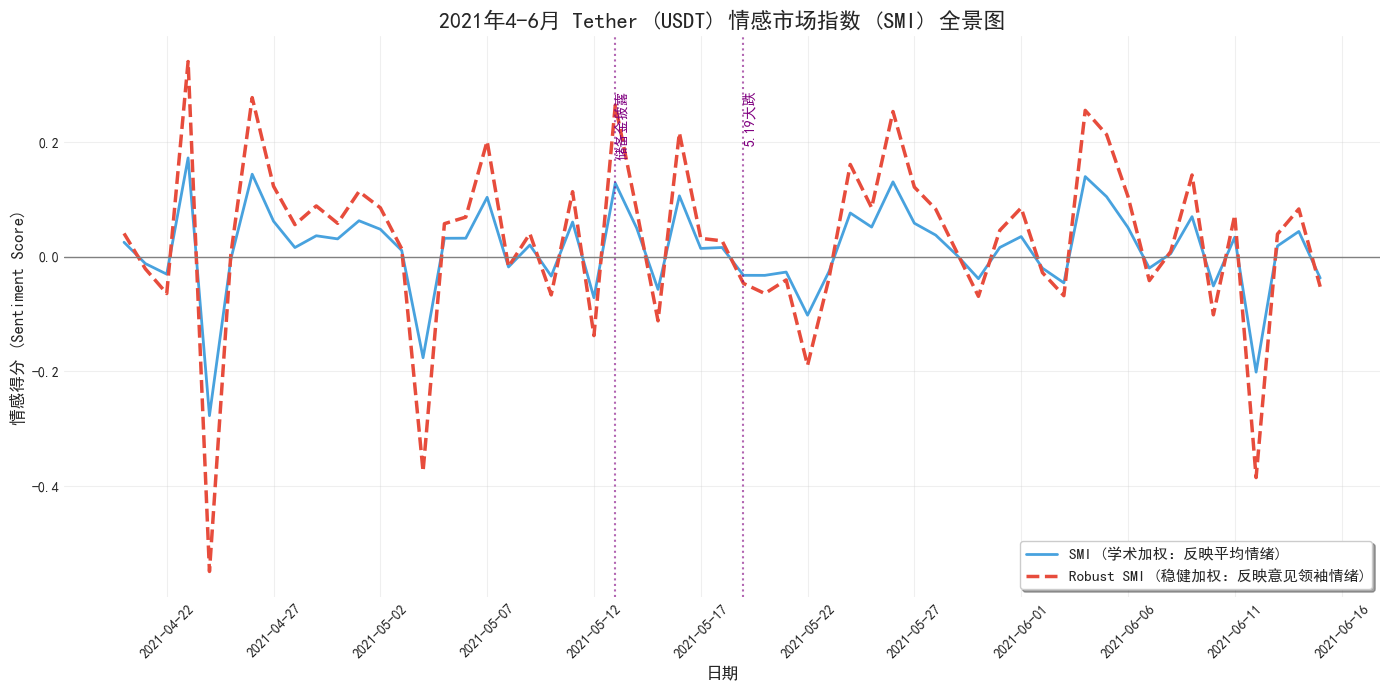

✅ 图2已保存: SMI_Zoomed_Event_Updated.png


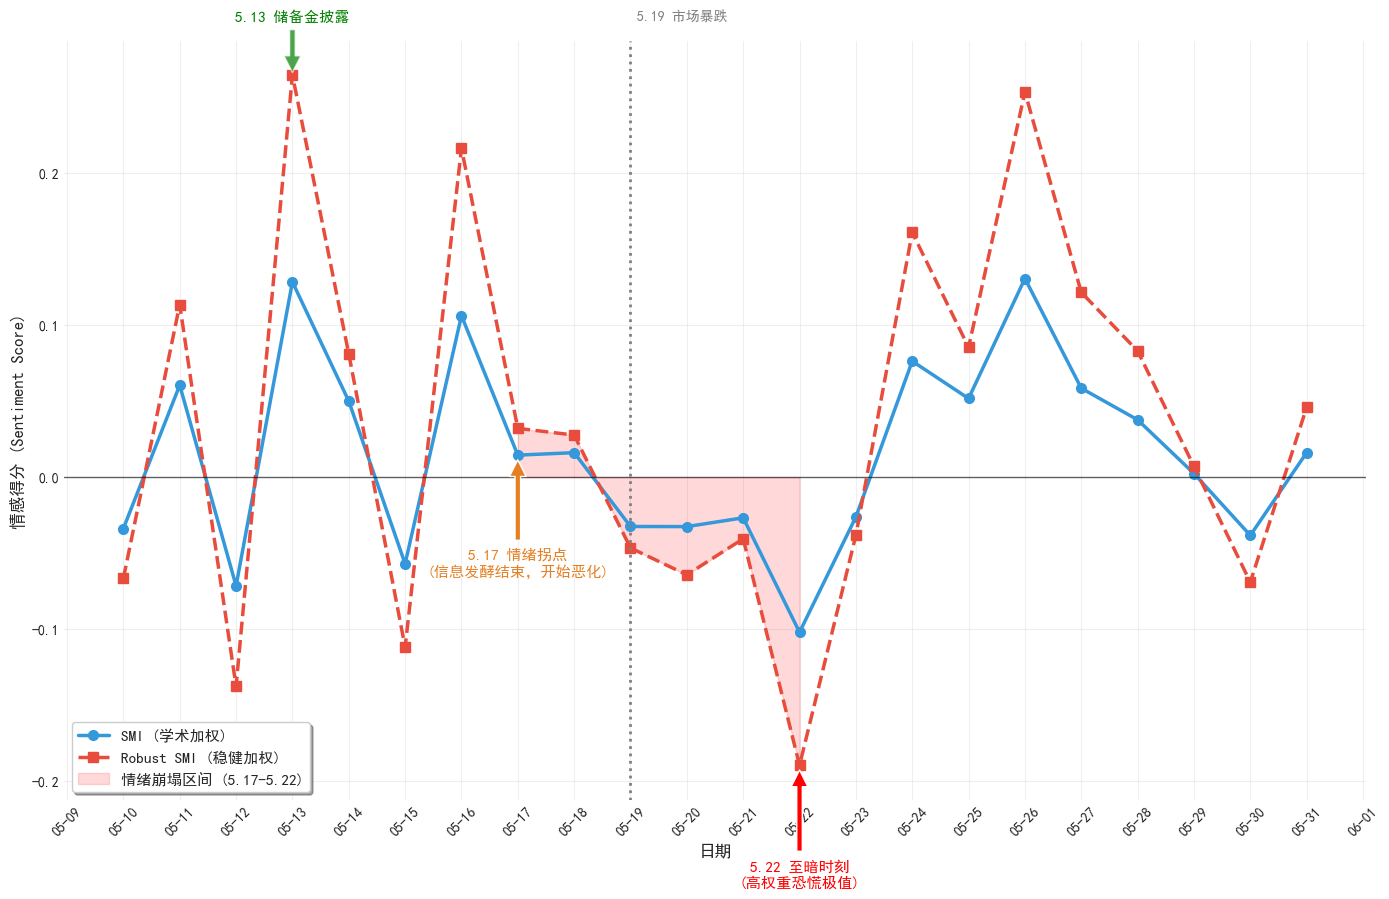

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# ==================== 绘图配置 ====================
# 设置风格和字体（解决中文乱码）
sns.set_style("whitegrid")
# 优先尝试 Mac 的字体，如果报错再尝试 Windows 的 SimHei
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 假设 daily_smi 和 daily_smi_robust 已经在内存中 (如果没有，请确保运行了前面的计算代码)
# 这里为了确保绘图代码独立运行，重新构建绘图数据 DataFrame
plot_data = pd.DataFrame({
    'Date': daily_smi.index,
    'SMI': daily_smi.values,
    'Robust_SMI': daily_smi_robust.values
}).sort_values('Date')

# ==================== 图1：全样本时间窗口 SMI 走势 ====================
plt.figure(figsize=(14, 7))

# 绘制两条线
plt.plot(plot_data['Date'], plot_data['SMI'], 
         label='SMI (学术加权：反映平均情绪)', color='#3498db', linewidth=2, alpha=0.9)
plt.plot(plot_data['Date'], plot_data['Robust_SMI'], 
         label='Robust SMI (稳健加权：反映意见领袖情绪)', color='#e74c3c', linewidth=2.5, linestyle='--')

# 添加0轴基准线
plt.axhline(0, color='gray', linestyle='-', linewidth=1)

# 标注关键事件
events = {
    '2021-05-13': '储备金披露',
    '2021-05-19': '5.19大跌'
}
for date_str, text in events.items():
    date_obj = pd.to_datetime(date_str)
    if date_obj in plot_data['Date'].values:
        plt.axvline(date_obj, color='purple', linestyle=':', alpha=0.6)
        # 将文字稍微放高一点，避免遮挡
        plt.text(date_obj, plot_data['Robust_SMI'].max()*0.85, text, 
                 rotation=90, verticalalignment='top', fontsize=10, color='purple', fontweight='bold')

plt.title('2021年4-6月 Tether (USDT) 情感市场指数 (SMI) 全景图', fontsize=16, fontweight='bold')
plt.ylabel('情感得分 (Sentiment Score)', fontsize=12)
plt.xlabel('日期', fontsize=12)
plt.legend(loc='lower right', frameon=True, fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)

# 设置日期格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('SMI_Full_Range_Updated.png', dpi=300)
print("✅ 图1已保存: SMI_Full_Range_Updated.png")
plt.show()

# ==================== 图2：局部放大（事件冲击窗口） ====================
# 筛选时间窗口：5月10日 - 5月31日
start_date = '2021-05-10'
end_date = '2021-05-31'
mask = (plot_data['Date'] >= start_date) & (plot_data['Date'] <= end_date)
zoom_data = plot_data.loc[mask]

plt.figure(figsize=(14, 9)) # 稍微加高一点，容纳更多标注

# 绘制折线
plt.plot(zoom_data['Date'], zoom_data['SMI'], 
         marker='o', markersize=7, label='SMI (学术加权)', color='#3498db', linewidth=2.5)
plt.plot(zoom_data['Date'], zoom_data['Robust_SMI'], 
         marker='s', markersize=7, label='Robust SMI (稳健加权)', color='#e74c3c', linewidth=2.5, linestyle='--')

# 0轴
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.6)

# --- 核心标注：配合新的论文叙事 ---

# 1. 标注 5.13 披露日 (短暂回升)
disclosure_date = pd.to_datetime('2021-05-13')
if disclosure_date in zoom_data['Date'].values:
    # 获取当日 Robust SMI 值用于定位
    val_13 = zoom_data[zoom_data['Date'] == disclosure_date]['Robust_SMI'].values[0]
    plt.annotate('5.13 储备金披露', 
                 xy=(disclosure_date, val_13), xytext=(disclosure_date, val_13 + 0.035),
                 arrowprops=dict(facecolor='green', shrink=0.05, alpha=0.7),
                 fontsize=11, color='green', fontweight='bold', ha='center')

# 2. 标注 5.17 情绪拐点 (开始恶化)
turning_date = pd.to_datetime('2021-05-17')
if turning_date in zoom_data['Date'].values:
    val_17 = zoom_data[zoom_data['Date'] == turning_date]['SMI'].values[0] # 用蓝线定位，因为蓝线开始转折明显
    plt.annotate('5.17 情绪拐点\n(信息发酵结束，开始恶化)', 
                 xy=(turning_date, val_17), xytext=(turning_date, val_17 - 0.08),
                 arrowprops=dict(facecolor='#e67e22', shrink=0.05),
                 fontsize=11, color='#e67e22', fontweight='bold', ha='center')

# 3. 标注 5.19 市场大跌
crash_date = pd.to_datetime('2021-05-19')
plt.axvline(crash_date, color='gray', linestyle=':', linewidth=2)
plt.text(crash_date, 0.3, ' 5.19 市场暴跌', color='gray', fontsize=10, fontweight='bold', ha='left')

# 4. 标注 5.22 至暗时刻 (Robust SMI 触底)
bottom_date = pd.to_datetime('2021-05-22')
if bottom_date in zoom_data['Date'].values:
    val_22 = zoom_data[zoom_data['Date'] == bottom_date]['Robust_SMI'].values[0]
    plt.annotate('5.22 至暗时刻\n(高权重恐慌极值)', 
                 xy=(bottom_date, val_22), xytext=(bottom_date, val_22 - 0.08),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 fontsize=11, color='red', fontweight='bold', ha='center')

# 区域填充：标示“情绪崩塌”区间 (从拐点 5.17 到 谷底 5.22)
plt.fill_between(zoom_data['Date'], zoom_data['Robust_SMI'], 0, 
                 where=(zoom_data['Date'] >= turning_date) & (zoom_data['Date'] <= bottom_date),
                 color='red', alpha=0.15, label='情绪崩塌区间 (5.17-5.22)')

# plt.title('事件冲击窗口：意见领袖放大效应与情绪崩塌路径 (2021.5.10 - 5.31)', fontsize=16, fontweight='bold')
plt.ylabel('情感得分 (Sentiment Score)', fontsize=12)
plt.xlabel('日期', fontsize=12)
plt.legend(loc='lower left', frameon=True, fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)

# 设置日期格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1)) # 每天一个刻度
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('SMI_Zoomed_Event_Updated.png', dpi=300)
print("✅ 图2已保存: SMI_Zoomed_Event_Updated.png")
plt.show() 


✅ 可视化完成！图表已保存为 'sentiment_analysis_dashboard_FinBERT.png'


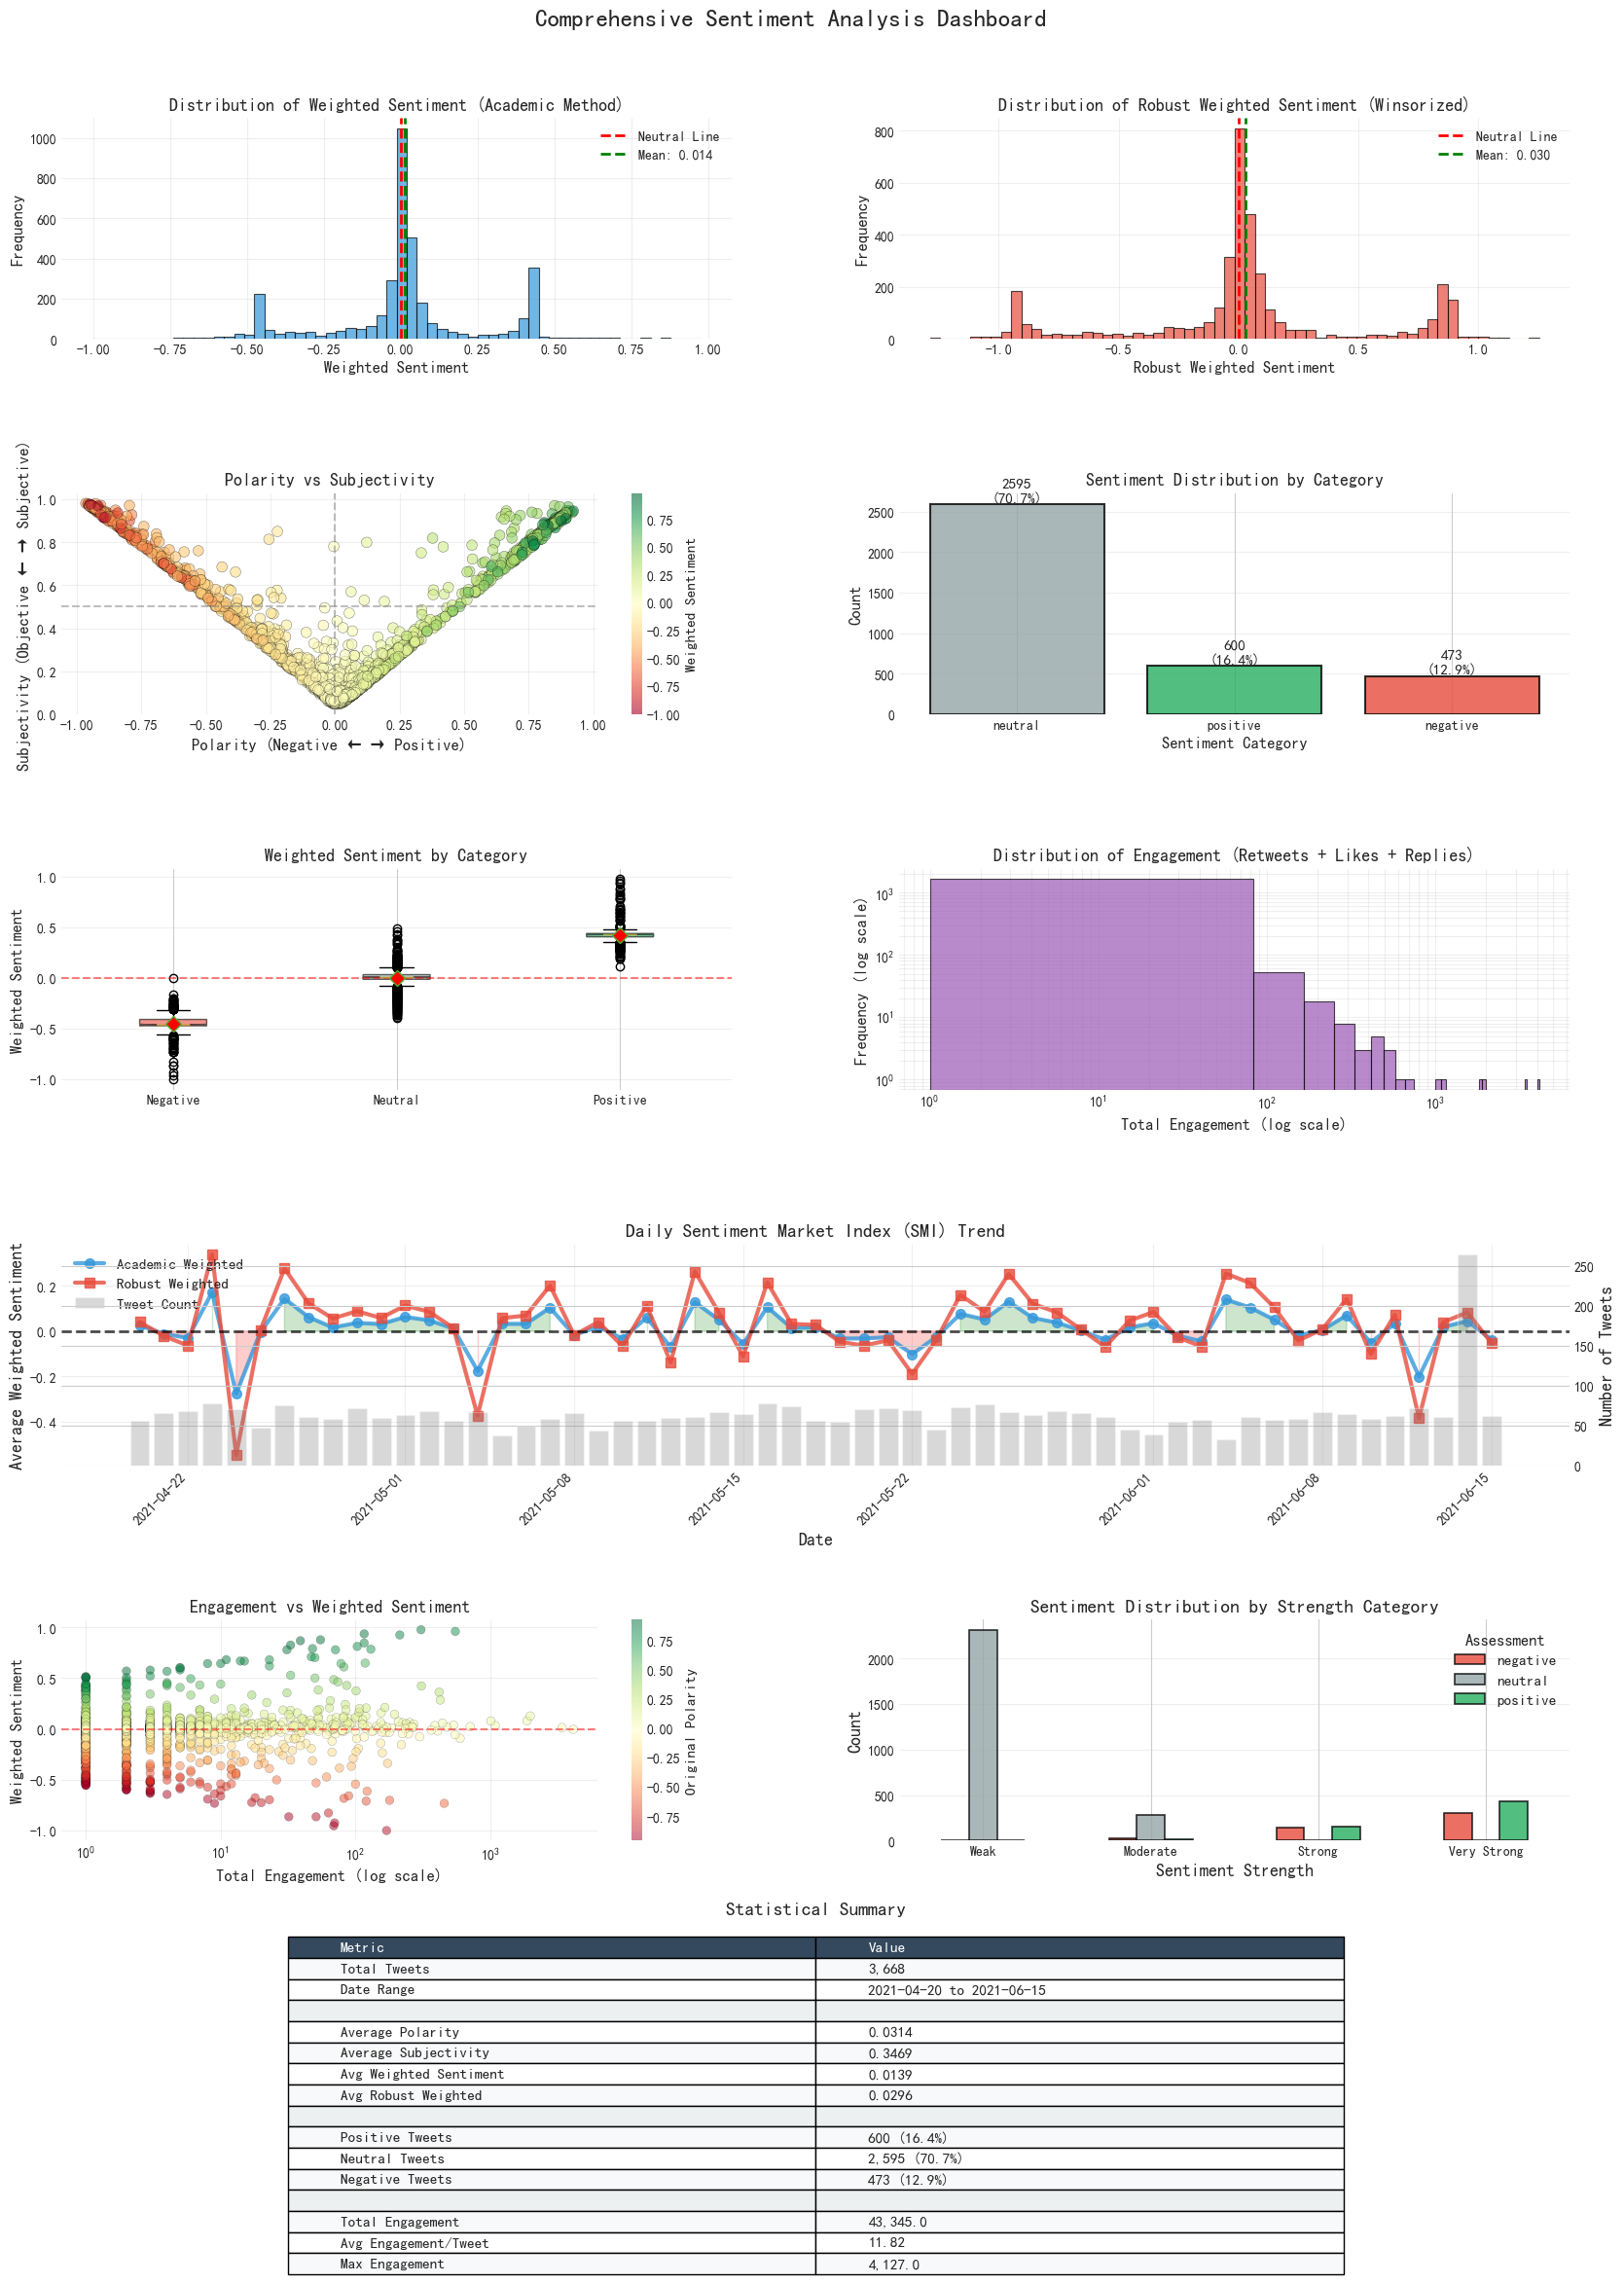

In [35]:
# ==================== 创建综合可视化（两列布局）====================
fig = plt.figure(figsize=(20, 28))  # 增加高度以容纳更大的间距
gs = fig.add_gridspec(6, 2, hspace=0.7, wspace=0.25)  # 6行2列

# -------------------- 1. Weighted Sentiment 分布 --------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_FinBERT['weighted_sentiment'], bins=60, color='#3498db', 
         edgecolor='black', alpha=0.7, linewidth=0.8)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral Line')
ax1.axvline(df_FinBERT['weighted_sentiment'].mean(), color='green', 
            linestyle='--', linewidth=2, label=f'Mean: {df_FinBERT["weighted_sentiment"].mean():.3f}')
ax1.set_xlabel('Weighted Sentiment', fontweight='bold', fontsize=12)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax1.set_title('Distribution of Weighted Sentiment (Academic Method)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# -------------------- 2. Robust Weighted Sentiment 分布 --------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_FinBERT['weighted_sentiment_robust'], bins=60, color='#e74c3c', 
         edgecolor='black', alpha=0.7, linewidth=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral Line')
ax2.axvline(df_FinBERT['weighted_sentiment_robust'].mean(), color='green', 
            linestyle='--', linewidth=2, label=f'Mean: {df_FinBERT["weighted_sentiment_robust"].mean():.3f}')
ax2.set_xlabel('Robust Weighted Sentiment', fontweight='bold', fontsize=12)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax2.set_title('Distribution of Robust Weighted Sentiment (Winsorized)', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# -------------------- 3. Polarity vs Subjectivity 散点图 --------------------
ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(df_FinBERT['polarity'], df_FinBERT['subjectivity'], 
                     c=df_FinBERT['weighted_sentiment'], cmap='RdYlGn', 
                     alpha=0.6, s=60, edgecolors='black', linewidth=0.3)
ax3.set_xlabel('Polarity (Negative ← → Positive)', fontweight='bold', fontsize=12)
ax3.set_ylabel('Subjectivity (Objective ← → Subjective)', fontweight='bold', fontsize=12)
ax3.set_title('Polarity vs Subjectivity', fontsize=13, fontweight='bold')
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(0, color='gray', linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Weighted Sentiment', fontweight='bold', fontsize=11)
ax3.grid(alpha=0.3)

# -------------------- 4. Assessment 分类统计 --------------------
ax4 = fig.add_subplot(gs[1, 1])
assessment_counts = df_FinBERT['assessment'].value_counts()
colors_map = {'positive': '#27ae60', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
bars = ax4.bar(assessment_counts.index, assessment_counts.values,
               color=[colors_map.get(x, 'gray') for x in assessment_counts.index],
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_xlabel('Sentiment Category', fontweight='bold', fontsize=12)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_title('Sentiment Distribution by Category', fontsize=13, fontweight='bold')
# 添加百分比标签
total = assessment_counts.sum()
for bar, count in zip(bars, assessment_counts.values):
    height = bar.get_height()
    percentage = (count / total) * 100
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# -------------------- 5. Weighted Sentiment 箱线图 --------------------
ax5 = fig.add_subplot(gs[2, 0])
box_data = [df_FinBERT[df_FinBERT['assessment'] == cat]['weighted_sentiment'].values 
            for cat in ['negative', 'neutral', 'positive']]
bp = ax5.boxplot(box_data, labels=['Negative', 'Neutral', 'Positive'],
                 patch_artist=True, notch=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
for patch, color in zip(bp['boxes'], ['#e74c3c', '#95a5a6', '#27ae60']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax5.set_ylabel('Weighted Sentiment', fontweight='bold', fontsize=12)
ax5.set_title('Weighted Sentiment by Category', fontsize=13, fontweight='bold')
ax5.axhline(0, color='red', linestyle='--', alpha=0.5)
ax5.grid(axis='y', alpha=0.3)

# -------------------- 6. 互动量分布（对数尺度）--------------------
ax6 = fig.add_subplot(gs[2, 1])
engagement_positive = df_FinBERT[df_FinBERT['total_engagement'] > 0]['total_engagement']
ax6.hist(engagement_positive, bins=50, color='#9b59b6', 
         edgecolor='black', alpha=0.7, linewidth=0.8)
ax6.set_xlabel('Total Engagement (log scale)', fontweight='bold', fontsize=12)
ax6.set_ylabel('Frequency (log scale)', fontweight='bold', fontsize=12)
ax6.set_title('Distribution of Engagement (Retweets + Likes + Replies)', 
              fontsize=13, fontweight='bold')
ax6.set_yscale('log')
ax6.set_xscale('log')
ax6.grid(alpha=0.3, which='both')

# -------------------- 7. 每日平均情感趋势（跨两列）--------------------
ax7 = fig.add_subplot(gs[3, :])
daily_smi = df_FinBERT.groupby('Date')['weighted_sentiment'].mean()
daily_smi_robust = df_FinBERT.groupby('Date')['weighted_sentiment_robust'].mean()
daily_count = df_FinBERT.groupby('Date').size()

ax7_twin = ax7.twinx()

# 绘制情感趋势线
line1 = ax7.plot(daily_smi.index, daily_smi.values, 
                 marker='o', linewidth=3, markersize=7, 
                 color='#3498db', label='Academic Weighted', alpha=0.8)
line2 = ax7.plot(daily_smi_robust.index, daily_smi_robust.values, 
                 marker='s', linewidth=3, markersize=7, 
                 color='#e74c3c', label='Robust Weighted', alpha=0.8)

# 绘制推文数量柱状图
bars = ax7_twin.bar(daily_count.index, daily_count.values, 
                    alpha=0.3, color='gray', label='Tweet Count', width=0.8)

ax7.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax7.fill_between(daily_smi.index, daily_smi.values, 0, 
                 where=(daily_smi.values > 0), alpha=0.2, color='green')
ax7.fill_between(daily_smi.index, daily_smi.values, 0, 
                 where=(daily_smi.values < 0), alpha=0.2, color='red')

ax7.set_xlabel('Date', fontweight='bold', fontsize=13)
ax7.set_ylabel('Average Weighted Sentiment', fontweight='bold', fontsize=13)
ax7_twin.set_ylabel('Number of Tweets', fontweight='bold', fontsize=13)
ax7.set_title('Daily Sentiment Market Index (SMI) Trend', 
              fontsize=14, fontweight='bold')

# 合并图例
lines1, labels1 = ax7.get_legend_handles_labels()
lines2, labels2 = ax7_twin.get_legend_handles_labels()
ax7.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax7.grid(alpha=0.3)
plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')

# -------------------- 8. 互动量 vs 加权情感 --------------------
ax8 = fig.add_subplot(gs[4, 0])
# 过滤有互动的推文
df_FinBERT_engaged = df_FinBERT[df_FinBERT['total_engagement'] > 0].copy()
scatter2 = ax8.scatter(df_FinBERT_engaged['total_engagement'], 
                      df_FinBERT_engaged['weighted_sentiment'],
                      c=df_FinBERT_engaged['polarity'], cmap='RdYlGn',
                      alpha=0.5, s=40, edgecolors='black', linewidth=0.2)
ax8.set_xlabel('Total Engagement (log scale)', fontweight='bold', fontsize=12)
ax8.set_ylabel('Weighted Sentiment', fontweight='bold', fontsize=12)
ax8.set_title('Engagement vs Weighted Sentiment', fontsize=13, fontweight='bold')
ax8.set_xscale('log')
ax8.axhline(0, color='red', linestyle='--', alpha=0.5)
cbar2 = plt.colorbar(scatter2, ax=ax8)
cbar2.set_label('Original Polarity', fontweight='bold', fontsize=11)
ax8.grid(alpha=0.3)

# -------------------- 9. 情感强度分布（原 ax10，现在在 ax9 位置）--------------------
ax9 = fig.add_subplot(gs[4, 1])

# 创建情感强度分类
df_FinBERT['sentiment_strength'] = df_FinBERT['polarity'].abs()
bins = [0, 0.2, 0.5, 0.8, 1.0]
labels_strength = ['Weak', 'Moderate', 'Strong', 'Very Strong']
df_FinBERT['strength_category'] = pd.cut(df_FinBERT['sentiment_strength'], bins=bins, labels=labels_strength)

# 按强度和极性分组
strength_sentiment = pd.crosstab(df_FinBERT['strength_category'], df_FinBERT['assessment'])

strength_sentiment.plot(kind='bar', stacked=False, ax=ax9, 
                       color=['#e74c3c', '#95a5a6', '#27ae60'],
                       edgecolor='black', linewidth=1.2, alpha=0.8)
ax9.set_xlabel('Sentiment Strength', fontweight='bold', fontsize=13)
ax9.set_ylabel('Count', fontweight='bold', fontsize=13)
ax9.set_title('Sentiment Distribution by Strength Category', fontsize=14, fontweight='bold')
ax9.legend(title='Assessment', fontsize=11, title_fontsize=12)
ax9.grid(axis='y', alpha=0.3)
plt.setp(ax9.xaxis.get_majorticklabels(), rotation=0)

# -------------------- 10. 统计摘要表（原 ax9，现在在 ax10 位置，增大间距）--------------------
# 使用 subplot2grid 来单独控制这个子图的位置和间距
# -------------------- 10. 统计摘要表（调整位置和大小）--------------------
ax10 = plt.subplot2grid((6, 2), (5, 0), colspan=2, rowspan=1, fig=fig)
ax10.axis('off')

# 计算统计数据
stats_data = [
    ['Metric', 'Value'],
    ['Total Tweets', f'{len(df_FinBERT):,}'],
    ['Date Range', f'{df_FinBERT["Date"].min().date()} to {df_FinBERT["Date"].max().date()}'],
    ['', ''],
    ['Average Polarity', f'{df_FinBERT["polarity"].mean():.4f}'],
    ['Average Subjectivity', f'{df_FinBERT["subjectivity"].mean():.4f}'],
    ['Avg Weighted Sentiment', f'{df_FinBERT["weighted_sentiment"].mean():.4f}'],
    ['Avg Robust Weighted', f'{df_FinBERT["weighted_sentiment_robust"].mean():.4f}'],
    ['', ''],
    ['Positive Tweets', f'{(df_FinBERT["assessment"] == "positive").sum():,} ({(df_FinBERT["assessment"] == "positive").sum()/len(df_FinBERT)*100:.1f}%)'],
    ['Neutral Tweets', f'{(df_FinBERT["assessment"] == "neutral").sum():,} ({(df_FinBERT["assessment"] == "neutral").sum()/len(df_FinBERT)*100:.1f}%)'],
    ['Negative Tweets', f'{(df_FinBERT["assessment"] == "negative").sum():,} ({(df_FinBERT["assessment"] == "negative").sum()/len(df_FinBERT)*100:.1f}%)'],
    ['', ''],
    ['Total Engagement', f'{df_FinBERT["total_engagement"].sum():,}'],
    ['Avg Engagement/Tweet', f'{df_FinBERT["total_engagement"].mean():.2f}'],
    ['Max Engagement', f'{df_FinBERT["total_engagement"].max():,}'],
]

table = ax10.table(cellText=stats_data, cellLoc='left', loc='center',
                  colWidths=[0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.3)  # 调整表格高度

# 设置表格样式
for i in range(len(stats_data)):
    if i == 0:
        table[(i, 0)].set_facecolor('#34495e')
        table[(i, 1)].set_facecolor('#34495e')
        table[(i, 0)].set_text_props(weight='bold', color='white')
        table[(i, 1)].set_text_props(weight='bold', color='white')
    elif stats_data[i][0] == '':
        table[(i, 0)].set_facecolor('#ecf0f1')
        table[(i, 1)].set_facecolor('#ecf0f1')
    else:
        table[(i, 0)].set_facecolor('#ffffff' if i % 2 == 0 else '#f8f9fa')
        table[(i, 1)].set_facecolor('#ffffff' if i % 2 == 0 else '#f8f9fa')

# 增加标题与表格的间距
ax10.set_title('Statistical Summary', fontsize=14, fontweight='bold', pad=60)

# ==================== 保存图表 ====================
plt.suptitle('Comprehensive Sentiment Analysis Dashboard',
             fontsize=18, fontweight='bold', y=0.92)

plt.savefig('sentiment_analysis_dashboard_FinBERT.png', dpi=300, bbox_inches='tight')
print("\n✅ 可视化完成！图表已保存为 'sentiment_analysis_dashboard_FinBERT.png'")

plt.show()


In [55]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns 

In [56]:
df_tether = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\tether.csv') 
df_bitcoin = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\bitcoin.csv') 
df_ethereum = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\ethereum.csv') 
df_usd_coin = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\usd coin.csv') 

In [57]:
# ==================== 数据筛选 ====================
def filter_date_range(df, start_date='2021-04-20', end_date='2021-06-15'):
    """筛选指定日期范围的数据"""
    df['Date'] = pd.to_datetime(df['Date'])
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    return df.loc[mask].copy() 

# 筛选数据
df_tether_filtered = filter_date_range(df_tether)
df_bitcoin_filtered = filter_date_range(df_bitcoin)
df_ethereum_filtered = filter_date_range(df_ethereum) 
df_usd_coin_filtered = filter_date_range(df_usd_coin) 

In [58]:
# ==================== 数据清洗 ====================
def clean_crypto_data(df, coin_name):
    """清洗加密货币数据"""
    df = df.copy()
    
    # 1. 转换日期格式
    df['Date'] = pd.to_datetime(df['Date'])
    
    # 2. 按日期排序
    df = df.sort_values('Date').reset_index(drop=True)
    
    # 3. 检查缺失值
    print(f"\n{coin_name} 缺失值统计:")
    print(df.isnull().sum())
    
    # 4. 处理缺失值（前向填充）
    df = df.ffill()
    
    # 5. 检查异常值
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in numeric_cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            if len(outliers) > 0:
                print(f"\n{coin_name} {col} 发现 {len(outliers)} 个异常值")
                print(outliers[['Date', col]])
    
    # 6. 重命名列（添加币种前缀）
    rename_dict = {
        'Open': f'{coin_name}_Open',
        'High': f'{coin_name}_High',
        'Low': f'{coin_name}_Low',
        'Close': f'{coin_name}_Close',
        'Volume': f'{coin_name}_Volume'
    }
    df = df.rename(columns=rename_dict)
    
    return df

# 清洗所有数据
df_tether_clean = clean_crypto_data(df_tether_filtered, 'USDT')
df_bitcoin_clean = clean_crypto_data(df_bitcoin_filtered, 'BTC')
df_ethereum_clean = clean_crypto_data(df_ethereum_filtered, 'ETH')
df_usd_coin_clean = clean_crypto_data(df_usd_coin_filtered, 'USDC') 



USDT 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

USDT Volume 发现 1 个异常值
         Date      Volume
29 2021-05-19  1073871488

BTC 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

BTC Volume 发现 1 个异常值
         Date  Volume
29 2021-05-19  607096

ETH 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

USDC 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

USDC High 发现 3 个异常值
         Date    High
26 2021-05-16  1.0023
27 2021-05-17  1.0024
29 2021-05-19  1.0049

USDC Low 发现 2 个异常值
        Date     Low
0 2021-04-20  0.9847
1 2021-04-21  0.9950

USDC Volume 发现 1 个异常值
         Date     Volume
29 2021-05-19  829656448


In [59]:
# ==================== 合并数据 ====================
# 以 USDT 为基准，合并其他数据
master_df = df_tether_clean[['Date', 'USDT_Open', 'USDT_High', 'USDT_Low', 'USDT_Close', 'USDT_Volume']].copy()

# 合并 BTC 数据
master_df = pd.merge(master_df, 
                     df_bitcoin_clean[['Date', 'BTC_Close', 'BTC_Volume']], 
                     on='Date', how='left')

# 合并 ETH 数据
master_df = pd.merge(master_df, 
                     df_ethereum_clean[['Date', 'ETH_Close', 'ETH_Volume']], 
                     on='Date', how='left')

# 合并 USDC 数据
master_df = pd.merge(master_df, 
                     df_usd_coin_clean[['Date', 'USDC_Close', 'USDC_Volume']], 
                     on='Date', how='left')

print(f"\n合并后数据形状: {master_df.shape}")
print(f"合并后数据预览:")
print(master_df.head())

# 检查合并后的缺失值
print(f"\n合并后缺失值:")
print(master_df.isnull().sum()) 



合并后数据形状: (57, 12)
合并后数据预览:
        Date  USDT_Open  USDT_High  USDT_Low  USDT_Close  USDT_Volume  \
0 2021-04-20     1.0007     1.0019    1.0000      1.0008    390712736   
1 2021-04-21     1.0004     1.0007    0.9999      1.0002    266370048   
2 2021-04-22     1.0002     1.0010    0.9995      1.0004    386373984   
3 2021-04-23     1.0004     1.0016    0.9998      1.0008    507062112   
4 2021-04-24     1.0006     1.0024    1.0005      1.0018    150261312   

   BTC_Close  BTC_Volume  ETH_Close  ETH_Volume  USDC_Close  USDC_Volume  
0    56483.2      115485    2332.14     1858410      0.9989    231269264  
1    53820.2      100263    2360.81     2104047      0.9995    194637008  
2    51729.5      168125    2401.10     3165540      0.9998    240331904  
3    51143.6      214455    2367.31     3456897      0.9991    364535552  
4    50088.9       82250    2215.93     1614413      0.9988    109961768  

合并后缺失值:
Date           0
USDT_Open      0
USDT_High      0
USDT_Low       0
USDT_C

In [75]:
# ==================== 特征工程 (已修复数据泄露与样本损耗) ==================== 
def create_features(df):
    """创建所有特征"""
    df = df.copy()
    
    # ========== 1. 目标变量：USDT 脱锚程度 ==========
    df['USDT_Deviation'] = abs(df['USDT_Close'] - 1.00)  # 绝对偏离
    
    # ========== 2. 价格与对照组特征 ==========
    df['USDC_Deviation'] = abs(df['USDC_Close'] - 1.00)
    df['USDT_USDC_Spread'] = df['USDT_Close'] - df['USDC_Close']  # 价差
    
    # ========== 3. 收益率特征 ==========
    df['USDT_Return'] = df['USDT_Close'].pct_change()
    df['BTC_Return'] = df['BTC_Close'].pct_change()
    df['ETH_Return'] = df['ETH_Close'].pct_change()
    
    # ========== 4. 波动率特征 (最高保留7天，删去14天以保留样本量) ==========
    df['USDT_Volatility_3d'] = df['USDT_Return'].rolling(window=3).std()
    df['USDT_Volatility_7d'] = df['USDT_Return'].rolling(window=7).std()
    df['BTC_Volatility_7d'] = df['BTC_Return'].rolling(window=7).std()
    
    # ========== 5. 移动平均特征 (最高保留7天) ==========
    df['USDT_MA3'] = df['USDT_Close'].rolling(window=3).mean()
    df['USDT_MA7'] = df['USDT_Close'].rolling(window=7).mean()
    df['USDT_Deviation_MA7'] = df['USDT_Close'] - df['USDT_MA7']
    
    # ========== 6. 成交量特征 (新增对数处理，用于后续回归) ==========
    df['Log_USDT_Volume'] = np.log(df['USDT_Volume'])  # 新增：取对数平滑量级
 # USDT 成交量变化
    df['USDT_Volume_Change'] = df['USDT_Volume'].pct_change()
    df['USDT_Volume_MA7'] = df['USDT_Volume'].rolling(window=7).mean()
    df['USDT_Volume_Ratio'] = df['USDT_Volume'] / df['USDT_Volume_MA7']  # 成交量比率
    
    # ========== 7. 时间特征 ==========
    df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=周一, 6=周日
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    
    # ========== 8. 滞后特征 (改去Lag7，改为Lag4，对应我们的核心结论) ==========
    for lag in [1, 2, 3, 4]:
        df[f'USDT_Deviation_Lag{lag}'] = df['USDT_Deviation'].shift(lag)
        df[f'BTC_Return_Lag{lag}'] = df['BTC_Return'].shift(lag)

    # 注意：删除了原有的 MACD、RSI 和 布林带（因为它们需要 14-26 天的数据，会导致样本量腰斩）
    # 注意：删除了所有交互特征（如 USDT_Volume_x_Deviation），彻底解决 Data Leakage 数据泄露问题

    # ========== 9. 资金转移指标 ==========
    df['Flow_to_USDC'] = df['USDC_Volume'] / df['USDT_Volume']
    
    return df

# 创建特征
master_df = create_features(master_df)

print(f"\n特征工程后数据形状: {master_df.shape}")
print(f"特征列表:")
print(master_df.columns.tolist()) 


特征工程后数据形状: (57, 48)
特征列表:
['Date', 'USDT_Open', 'USDT_High', 'USDT_Low', 'USDT_Close', 'USDT_Volume', 'BTC_Close', 'BTC_Volume', 'ETH_Close', 'ETH_Volume', 'USDC_Close', 'USDC_Volume', 'USDT_Deviation', 'USDC_Deviation', 'USDT_USDC_Spread', 'USDT_Return', 'BTC_Return', 'ETH_Return', 'USDT_Volatility_3d', 'USDT_Volatility_7d', 'BTC_Volatility_7d', 'USDT_MA3', 'USDT_MA7', 'USDT_Deviation_MA7', 'Log_USDT_Volume', 'USDT_Volume_Change', 'DayOfWeek', 'IsWeekend', 'USDT_Deviation_Lag1', 'BTC_Return_Lag1', 'USDT_Deviation_Lag2', 'BTC_Return_Lag2', 'USDT_Deviation_Lag3', 'BTC_Return_Lag3', 'USDT_Deviation_Lag4', 'BTC_Return_Lag4', 'Flow_to_USDC', 'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Sentiment_Academic_SMI', 'Sentiment_Robust_SMI', 'Total_Engagement', 'Sentiment_Change', 'Sentiment_MA3', 'Sentiment_MA7', 'Sentiment_x_Deviation', 'USDT_Volume_MA7', 'USDT_Volume_Ratio']


In [76]:
# ==================== 整合舆情数据 ====================
# 假设你已经有了 FinBERT 分析的结果
# df_sentiment = pd.read_csv('tweets_with_sentiment_finbert.csv')

# 如果有舆情数据，进行合并
def merge_sentiment_data(master_df, sentiment_df):
    """合并舆情数据"""
    # 按日期聚合舆情数据
    daily_sentiment = sentiment_df.groupby('Date').agg({
        'polarity': 'mean',
        'subjectivity': 'mean',
        'weighted_sentiment': 'mean',
        'weighted_sentiment_robust': 'mean',
        'total_engagement': 'sum'
    }).reset_index()
    
    # 重命名列
    daily_sentiment.columns = [
        'Date', 
        'Sentiment_Polarity', 
        'Sentiment_Subjectivity',
        'Sentiment_Academic_SMI',
        'Sentiment_Robust_SMI',
        'Total_Engagement'
    ]
    
    # 转换日期格式
    daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])
    
    # 合并
    master_df = pd.merge(master_df, daily_sentiment, on='Date', how='left')
    
    # 创建舆情相关特征
    master_df['Sentiment_Change'] = master_df['Sentiment_Academic_SMI'].diff()
    master_df['Sentiment_MA3'] = master_df['Sentiment_Academic_SMI'].rolling(window=3).mean()
    master_df['Sentiment_MA7'] = master_df['Sentiment_Academic_SMI'].rolling(window=7).mean()
    
    # 舆情 × 价格偏离交互特征
    master_df['Sentiment_x_Deviation'] = master_df['Sentiment_Academic_SMI'] * master_df['USDT_Deviation']
    
    return master_df

# 如果有舆情数据，取消下面的注释
master_df = merge_sentiment_data(master_df, df_FinBERT) 


KeyError: 'Sentiment_Academic_SMI'

In [77]:
print(f"\n特征工程后数据形状: {master_df.shape}")
print(f"特征列表:")
print(master_df.columns.tolist())

# 查看前几行
print(f"\n数据预览:")
print(master_df.head(20)) 



特征工程后数据形状: (57, 48)
特征列表:
['Date', 'USDT_Open', 'USDT_High', 'USDT_Low', 'USDT_Close', 'USDT_Volume', 'BTC_Close', 'BTC_Volume', 'ETH_Close', 'ETH_Volume', 'USDC_Close', 'USDC_Volume', 'USDT_Deviation', 'USDC_Deviation', 'USDT_USDC_Spread', 'USDT_Return', 'BTC_Return', 'ETH_Return', 'USDT_Volatility_3d', 'USDT_Volatility_7d', 'BTC_Volatility_7d', 'USDT_MA3', 'USDT_MA7', 'USDT_Deviation_MA7', 'Log_USDT_Volume', 'USDT_Volume_Change', 'DayOfWeek', 'IsWeekend', 'USDT_Deviation_Lag1', 'BTC_Return_Lag1', 'USDT_Deviation_Lag2', 'BTC_Return_Lag2', 'USDT_Deviation_Lag3', 'BTC_Return_Lag3', 'USDT_Deviation_Lag4', 'BTC_Return_Lag4', 'Flow_to_USDC', 'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Sentiment_Academic_SMI', 'Sentiment_Robust_SMI', 'Total_Engagement', 'Sentiment_Change', 'Sentiment_MA3', 'Sentiment_MA7', 'Sentiment_x_Deviation', 'USDT_Volume_MA7', 'USDT_Volume_Ratio']

数据预览:
         Date  USDT_Open  USDT_High  USDT_Low  USDT_Close  USDT_Volume  \
0  2021-04-20     1.0007     1.0019

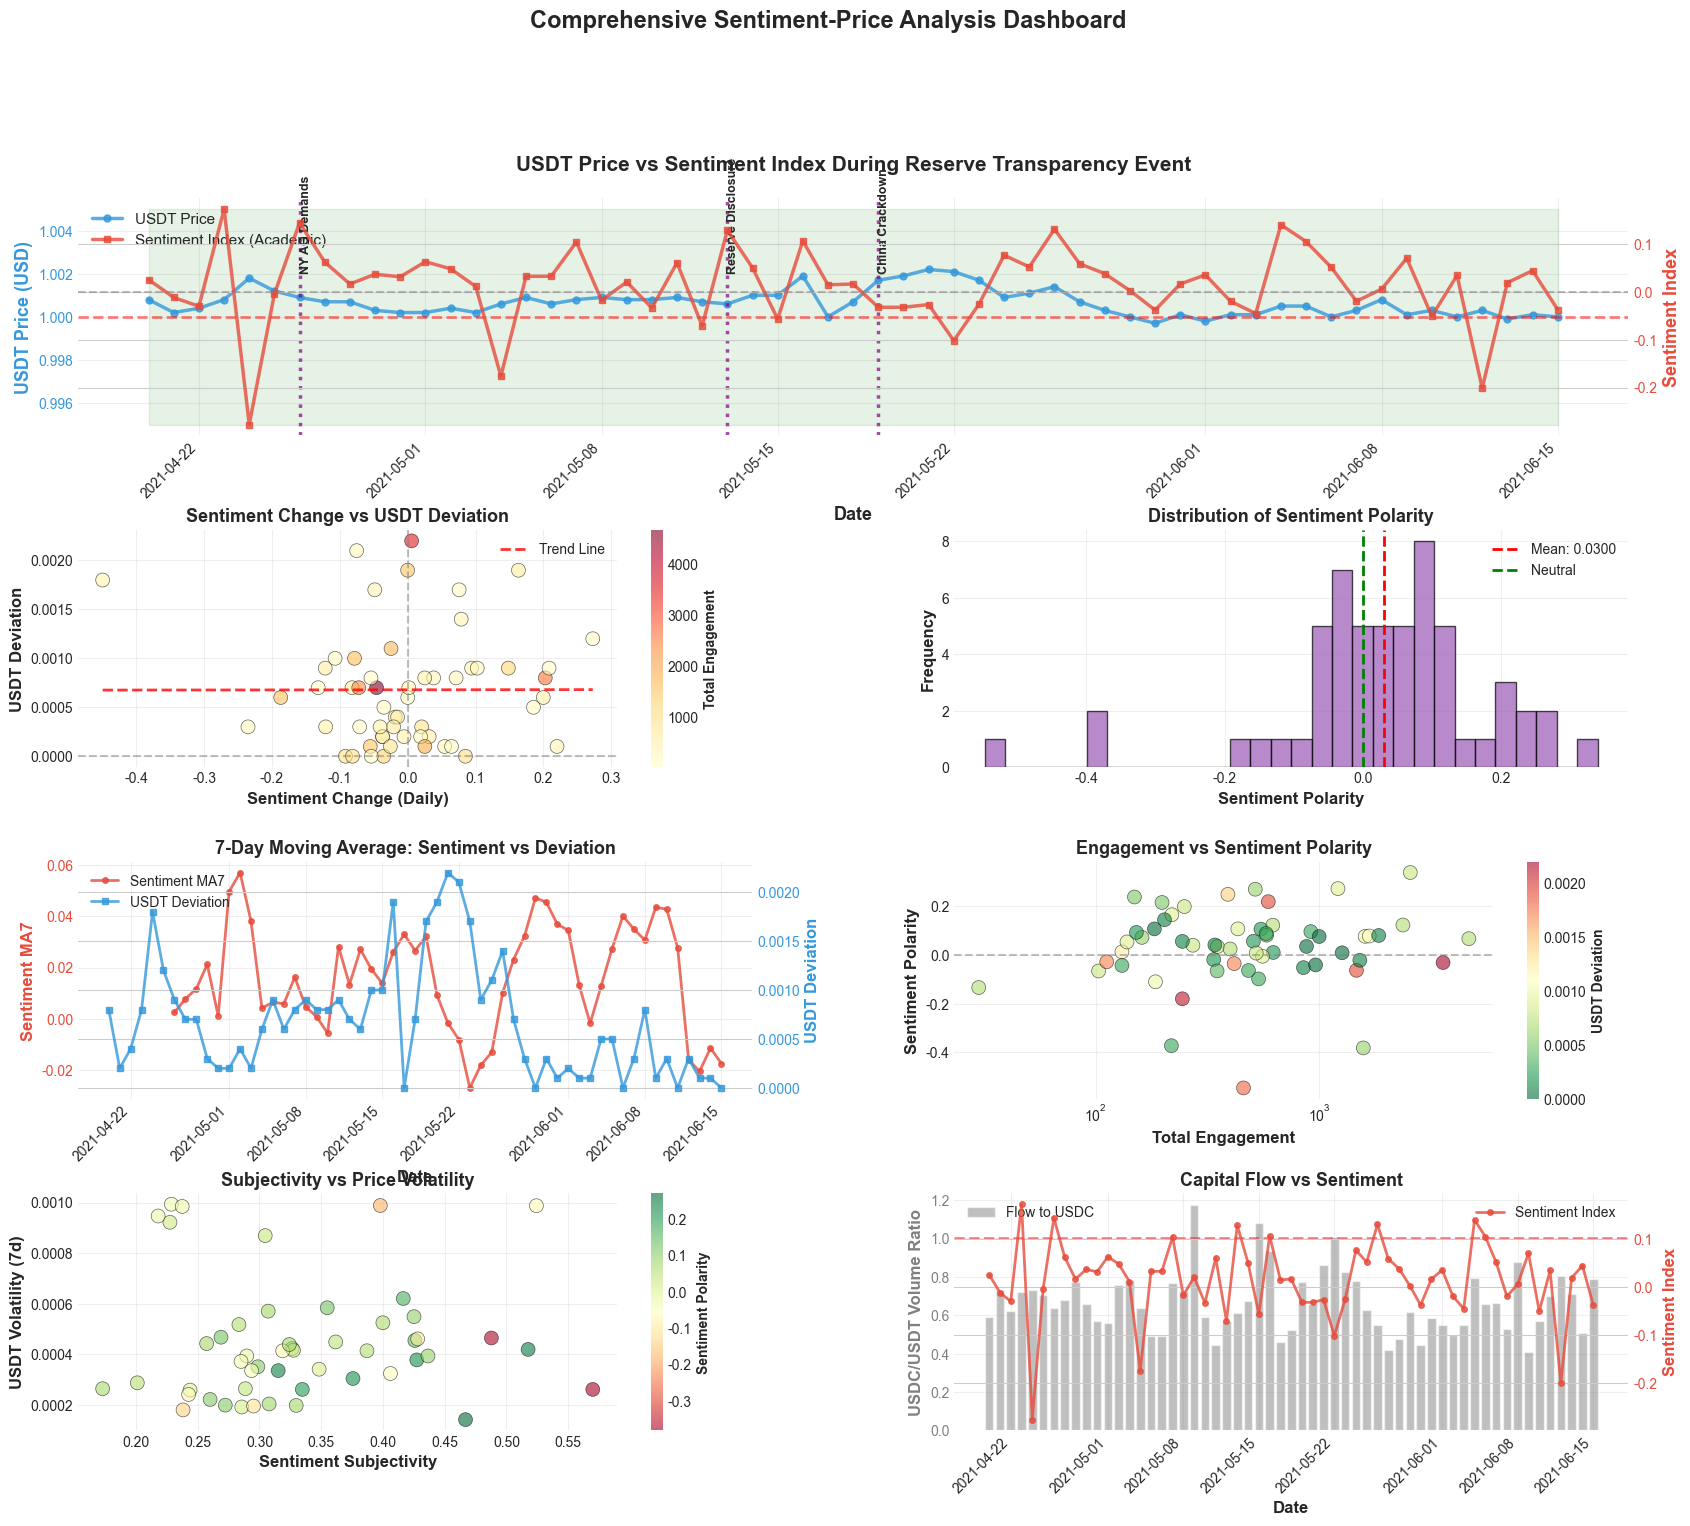

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# ==================== 1. 舆情与价格综合分析 ====================
def plot_sentiment_price_analysis(df):
    """舆情与价格的综合可视化"""
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)
    
    # 1.1 舆情指数与USDT价格时间序列（双轴）
    ax1 = fig.add_subplot(gs[0, :])
    ax1_twin = ax1.twinx()
    
    # USDT价格
    line1 = ax1.plot(df['Date'], df['USDT_Close'], 
                     linewidth=2.5, color='#3498db', marker='o', markersize=5,
                     label='USDT Price', alpha=0.8)
    ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='$1.00 Peg')
    ax1.fill_between(df['Date'], 0.995, 1.005, alpha=0.1, color='green', label='±0.5% Range')
    
    # 舆情指数
    line2 = ax1_twin.plot(df['Date'], df['Sentiment_Academic_SMI'], 
                          linewidth=2.5, color='#e74c3c', marker='s', markersize=5,
                          label='Sentiment Index (Academic)', alpha=0.8)
    ax1_twin.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    
    # 标注关键事件
    events = {
        '2021-04-26': 'NY AG Demands',
        '2021-05-13': 'Reserve Disclosure',
        '2021-05-19': 'China Crackdown'
    }
    
    for event_date, event_name in events.items():
        event_date = pd.to_datetime(event_date)
        if event_date in df['Date'].values:
            ax1.axvline(x=event_date, color='purple', linestyle=':', linewidth=2.5, alpha=0.7)
            ax1.text(event_date, 1.002, event_name, rotation=90, 
                    verticalalignment='bottom', fontsize=9, fontweight='bold')
    
    ax1.set_xlabel('Date', fontweight='bold', fontsize=13)
    ax1.set_ylabel('USDT Price (USD)', fontweight='bold', fontsize=13, color='#3498db')
    ax1_twin.set_ylabel('Sentiment Index', fontweight='bold', fontsize=13, color='#e74c3c')
    ax1.set_title('USDT Price vs Sentiment Index During Reserve Transparency Event', 
                  fontsize=15, fontweight='bold', pad=20)
    
    # 合并图例
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=11, framealpha=0.9)
    
    ax1.tick_params(axis='y', labelcolor='#3498db')
    ax1_twin.tick_params(axis='y', labelcolor='#e74c3c')
    ax1.grid(alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.2 舆情变化率与价格偏离
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(df['Sentiment_Change'], df['USDT_Deviation'], 
                c=df['Total_Engagement'], cmap='YlOrRd', s=100, 
                alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # 添加趋势线
    mask = ~np.isnan(df['Sentiment_Change']) & ~np.isnan(df['USDT_Deviation'])
    if mask.sum() > 0:
        z = np.polyfit(df.loc[mask, 'Sentiment_Change'], 
                      df.loc[mask, 'USDT_Deviation'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df['Sentiment_Change'].min(), 
                             df['Sentiment_Change'].max(), 100)
        ax2.plot(x_trend, p(x_trend), "r--", linewidth=2, alpha=0.8, label='Trend Line')
    
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Sentiment Change (Daily)', fontweight='bold', fontsize=12)
    ax2.set_ylabel('USDT Deviation', fontweight='bold', fontsize=12)
    ax2.set_title('Sentiment Change vs USDT Deviation', fontsize=13, fontweight='bold')
    cbar = plt.colorbar(ax2.collections[0], ax=ax2)
    cbar.set_label('Total Engagement', fontweight='bold', fontsize=10)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 1.3 舆情极性分布
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(df['Sentiment_Polarity'], bins=30, edgecolor='black', 
             alpha=0.7, color='#9b59b6')
    ax3.axvline(df['Sentiment_Polarity'].mean(), color='red', 
                linestyle='--', linewidth=2, 
                label=f'Mean: {df["Sentiment_Polarity"].mean():.4f}')
    ax3.axvline(0, color='green', linestyle='--', linewidth=2, label='Neutral')
    ax3.set_xlabel('Sentiment Polarity', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax3.set_title('Distribution of Sentiment Polarity', fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 1.4 舆情移动平均与价格偏离
    ax4 = fig.add_subplot(gs[2, 0])
    ax4_twin = ax4.twinx()
    
    line1 = ax4.plot(df['Date'], df['Sentiment_MA7'], 
                     linewidth=2, color='#e74c3c', marker='o', markersize=4,
                     label='Sentiment MA7', alpha=0.8)
    line2 = ax4_twin.plot(df['Date'], df['USDT_Deviation'], 
                          linewidth=2, color='#3498db', marker='s', markersize=4,
                          label='USDT Deviation', alpha=0.8)
    
    ax4.set_xlabel('Date', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Sentiment MA7', fontweight='bold', fontsize=12, color='#e74c3c')
    ax4_twin.set_ylabel('USDT Deviation', fontweight='bold', fontsize=12, color='#3498db')
    ax4.set_title('7-Day Moving Average: Sentiment vs Deviation', 
                  fontsize=13, fontweight='bold')
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax4.legend(lines, labels, loc='upper left', fontsize=10)
    
    ax4.tick_params(axis='y', labelcolor='#e74c3c')
    ax4_twin.tick_params(axis='y', labelcolor='#3498db')
    ax4.grid(alpha=0.3)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.5 互动量与舆情强度
    ax5 = fig.add_subplot(gs[2, 1])
    scatter = ax5.scatter(df['Total_Engagement'], df['Sentiment_Polarity'], 
                         c=df['USDT_Deviation'], cmap='RdYlGn_r', 
                         s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax5.set_xlabel('Total Engagement', fontweight='bold', fontsize=12)
    ax5.set_ylabel('Sentiment Polarity', fontweight='bold', fontsize=12)
    ax5.set_title('Engagement vs Sentiment Polarity', fontsize=13, fontweight='bold')
    ax5.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax5.set_xscale('log')
    cbar = plt.colorbar(scatter, ax=ax5)
    cbar.set_label('USDT Deviation', fontweight='bold', fontsize=10)
    ax5.grid(alpha=0.3)
    
    # 1.6 舆情主观性与价格波动
    ax6 = fig.add_subplot(gs[3, 0])
    ax6.scatter(df['Sentiment_Subjectivity'], df['USDT_Volatility_7d'], 
                c=df['Sentiment_Polarity'], cmap='RdYlGn', 
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax6.set_xlabel('Sentiment Subjectivity', fontweight='bold', fontsize=12)
    ax6.set_ylabel('USDT Volatility (7d)', fontweight='bold', fontsize=12)
    ax6.set_title('Subjectivity vs Price Volatility', fontsize=13, fontweight='bold')
    cbar = plt.colorbar(ax6.collections[0], ax=ax6)
    cbar.set_label('Sentiment Polarity', fontweight='bold', fontsize=10)
    ax6.grid(alpha=0.3)
    
    # 1.7 舆情与资金流向
    ax7 = fig.add_subplot(gs[3, 1])
    ax7_twin = ax7.twinx()
    
    line1 = ax7.bar(df['Date'], df['Flow_to_USDC'], 
                    alpha=0.5, color='gray', label='Flow to USDC', width=0.8)
    line2 = ax7_twin.plot(df['Date'], df['Sentiment_Academic_SMI'], 
                          linewidth=2, color='#e74c3c', marker='o', markersize=4,
                          label='Sentiment Index', alpha=0.8)
    
    ax7.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax7.set_xlabel('Date', fontweight='bold', fontsize=12)
    ax7.set_ylabel('USDC/USDT Volume Ratio', fontweight='bold', fontsize=12, color='gray')
    ax7_twin.set_ylabel('Sentiment Index', fontweight='bold', fontsize=12, color='#e74c3c')
    ax7.set_title('Capital Flow vs Sentiment', fontsize=13, fontweight='bold')
    
    ax7.legend(loc='upper left', fontsize=10)
    ax7_twin.legend(loc='upper right', fontsize=10)
    
    ax7.tick_params(axis='y', labelcolor='gray')
    ax7_twin.tick_params(axis='y', labelcolor='#e74c3c')
    ax7.grid(alpha=0.3)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.suptitle('Comprehensive Sentiment-Price Analysis Dashboard', 
                 fontsize=17, fontweight='bold', y=0.998)
    plt.savefig('sentiment_price_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# 运行可视化
plot_sentiment_price_analysis(master_df.dropna(subset=['Sentiment_Academic_SMI']))


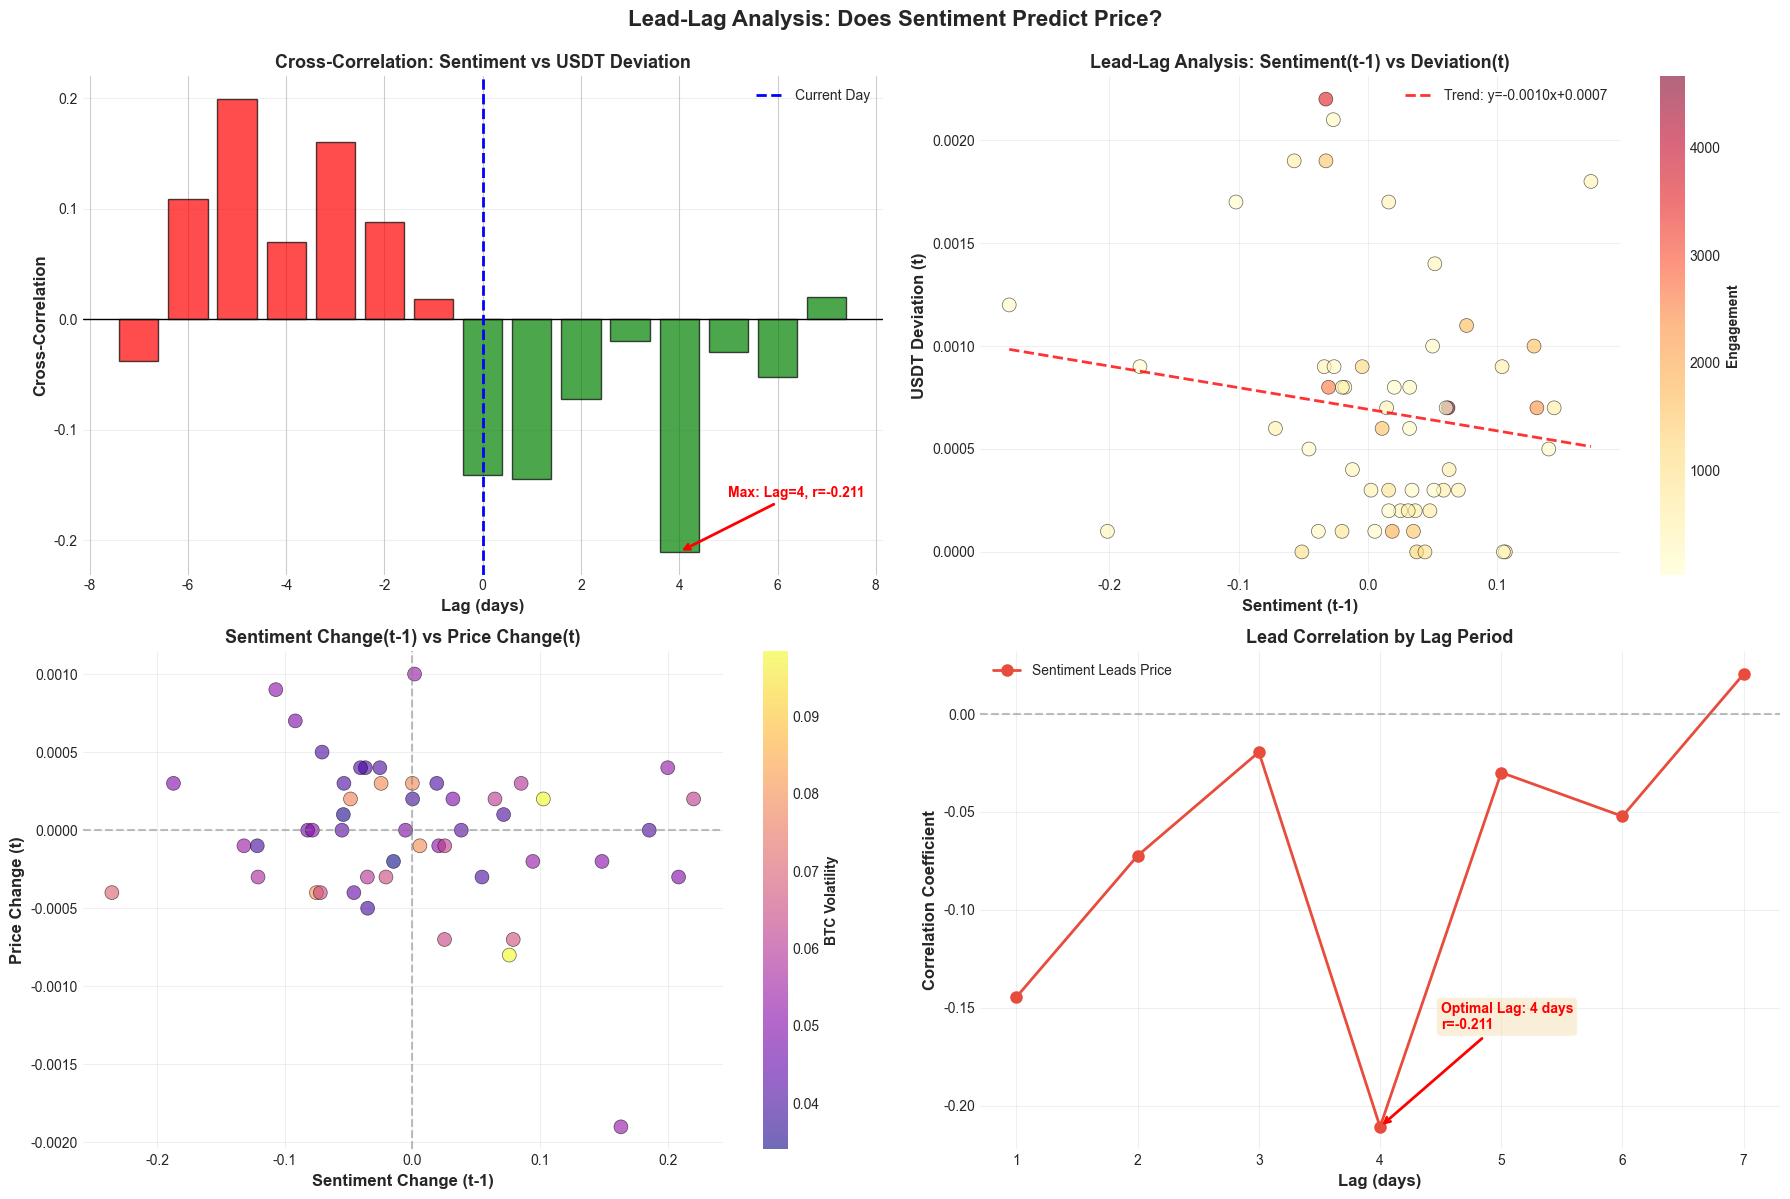


舆情领先性分析结果

最大交叉相关性:
  滞后期: 4 天
  相关系数: -0.2108

✅ 结论: 舆情领先价格 4 天
   解释: 舆情变化后 4 天，价格出现相应变化

不同滞后期的相关性:
  Lag 1: -0.1445
  Lag 2: -0.0723
  Lag 3: -0.0194
  Lag 4: -0.2108
  Lag 5: -0.0299
  Lag 6: -0.0522
  Lag 7: 0.0204


In [79]:
# ==================== 2. 舆情领先性分析 ====================
def plot_lead_lag_analysis(df):
    """分析舆情是否领先于价格变化"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 准备数据
    df_clean = df.dropna(subset=['Sentiment_Academic_SMI', 'USDT_Deviation'])
    
    # 2.1 交叉相关分析
    max_lag = 7
    correlations = []
    
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            # 舆情滞后（价格领先）
            corr = df_clean['Sentiment_Academic_SMI'].corr(
                df_clean['USDT_Deviation'].shift(-lag)
            )
        else:
            # 舆情领先（价格滞后）
            corr = df_clean['Sentiment_Academic_SMI'].shift(lag).corr(
                df_clean['USDT_Deviation']
            )
        correlations.append({'Lag': lag, 'Correlation': corr})
    
    corr_df = pd.DataFrame(correlations)
    
    # 绘制交叉相关图
    ax1 = axes[0, 0]
    colors = ['red' if x < 0 else 'green' for x in corr_df['Lag']]
    ax1.bar(corr_df['Lag'], corr_df['Correlation'], color=colors, 
            edgecolor='black', alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.axvline(x=0, color='blue', linestyle='--', linewidth=2, label='Current Day')
    ax1.set_xlabel('Lag (days)', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Cross-Correlation', fontweight='bold', fontsize=12)
    ax1.set_title('Cross-Correlation: Sentiment vs USDT Deviation', 
                  fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')
    
    # 标注最大相关性
    max_corr_idx = corr_df['Correlation'].abs().idxmax()
    max_lag = corr_df.loc[max_corr_idx, 'Lag']
    max_corr = corr_df.loc[max_corr_idx, 'Correlation']
    ax1.annotate(f'Max: Lag={max_lag}, r={max_corr:.3f}',
                xy=(max_lag, max_corr),
                xytext=(max_lag + 1, max_corr + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, fontweight='bold', color='red')
    
    # 2.2 舆情领先1天 vs 价格偏离
    ax2 = axes[0, 1]
    df_clean['Sentiment_Lead1'] = df_clean['Sentiment_Academic_SMI'].shift(1)
    ax2.scatter(df_clean['Sentiment_Lead1'], df_clean['USDT_Deviation'], 
                c=df_clean['Total_Engagement'], cmap='YlOrRd', 
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # 添加回归线
    mask = ~np.isnan(df_clean['Sentiment_Lead1']) & ~np.isnan(df_clean['USDT_Deviation'])
    if mask.sum() > 0:
        z = np.polyfit(df_clean.loc[mask, 'Sentiment_Lead1'], 
                      df_clean.loc[mask, 'USDT_Deviation'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df_clean['Sentiment_Lead1'].min(), 
                             df_clean['Sentiment_Lead1'].max(), 100)
        ax2.plot(x_trend, p(x_trend), "r--", linewidth=2, alpha=0.8, 
                label=f'Trend: y={z[0]:.4f}x+{z[1]:.4f}')
    
    ax2.set_xlabel('Sentiment (t-1)', fontweight='bold', fontsize=12)
    ax2.set_ylabel('USDT Deviation (t)', fontweight='bold', fontsize=12)
    ax2.set_title('Lead-Lag Analysis: Sentiment(t-1) vs Deviation(t)', 
                  fontsize=13, fontweight='bold')
    cbar = plt.colorbar(ax2.collections[0], ax=ax2)
    cbar.set_label('Engagement', fontweight='bold', fontsize=10)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 2.3 舆情变化领先 vs 价格变化
    ax3 = axes[1, 0]
    df_clean['Price_Change'] = df_clean['USDT_Close'].diff()
    df_clean['Sentiment_Change_Lead1'] = df_clean['Sentiment_Change'].shift(1)
    
    ax3.scatter(df_clean['Sentiment_Change_Lead1'], df_clean['Price_Change'], 
                c=df_clean['BTC_Volatility_7d'], cmap='plasma', 
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Sentiment Change (t-1)', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Price Change (t)', fontweight='bold', fontsize=12)
    ax3.set_title('Sentiment Change(t-1) vs Price Change(t)', 
                  fontsize=13, fontweight='bold')
    cbar = plt.colorbar(ax3.collections[0], ax=ax3)
    cbar.set_label('BTC Volatility', fontweight='bold', fontsize=10)
    ax3.grid(alpha=0.3)
    
    # 2.4 格兰杰因果检验结果可视化
    ax4 = axes[1, 1]
    
    # 计算不同滞后期的相关性
    lags = range(1, 8)
    lead_corrs = []
    
    for lag in lags:
        sentiment_lead = df_clean['Sentiment_Academic_SMI'].shift(lag)
        corr = sentiment_lead.corr(df_clean['USDT_Deviation'])
        lead_corrs.append(corr)
    
    ax4.plot(lags, lead_corrs, marker='o', linewidth=2, markersize=8, 
             color='#e74c3c', label='Sentiment Leads Price')
    ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Lag (days)', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Correlation Coefficient', fontweight='bold', fontsize=12)
    ax4.set_title('Lead Correlation by Lag Period', fontsize=13, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    # 标注最优滞后期
    max_idx = np.argmax(np.abs(lead_corrs))
    ax4.annotate(f'Optimal Lag: {lags[max_idx]} days\nr={lead_corrs[max_idx]:.3f}',
                xy=(lags[max_idx], lead_corrs[max_idx]),
                xytext=(lags[max_idx] + 0.5, lead_corrs[max_idx] + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, fontweight='bold', color='red',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Lead-Lag Analysis: Does Sentiment Predict Price?', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('lead_lag_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印分析结果
    print("\n" + "="*60)
    print("舆情领先性分析结果")
    print("="*60)
    print(f"\n最大交叉相关性:")
    print(f"  滞后期: {max_lag} 天")
    print(f"  相关系数: {max_corr:.4f}")
    
    if max_lag > 0:
        print(f"\n✅ 结论: 舆情领先价格 {max_lag} 天")
        print(f"   解释: 舆情变化后 {max_lag} 天，价格出现相应变化")
    elif max_lag < 0:
        print(f"\n❌ 结论: 价格领先舆情 {abs(max_lag)} 天")
        print(f"   解释: 价格变化后 {abs(max_lag)} 天，舆情才反应")
    else:
        print(f"\n⚠️ 结论: 舆情与价格同步变化")
    
    print(f"\n不同滞后期的相关性:")
    for lag, corr in zip(lags, lead_corrs):
        print(f"  Lag {lag}: {corr:.4f}")

# 运行领先性分析
plot_lead_lag_analysis(master_df) 


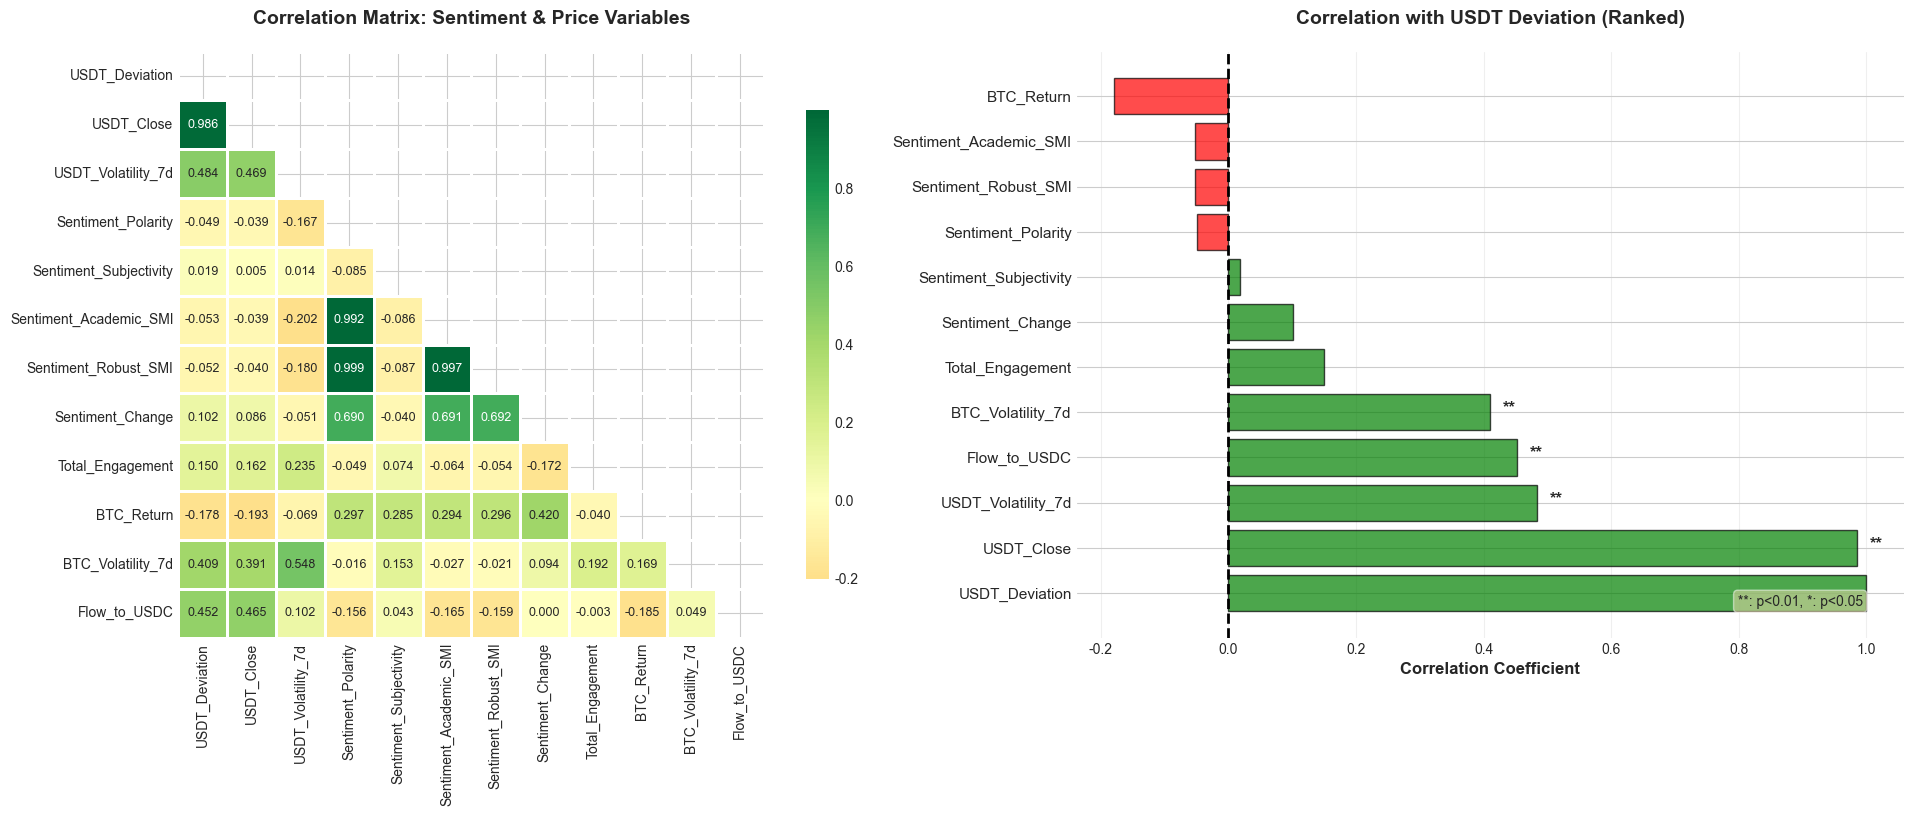


舆情变量与USDT偏离的相关性分析
USDT_Close                     | r= 0.9858 | p=0.0000 **（高度显著）
USDT_Volatility_7d             | r= 0.4844 | p=0.0004 **（高度显著）
Sentiment_Polarity             | r=-0.0494 | p=0.7332 （不显著）
Sentiment_Subjectivity         | r= 0.0189 | p=0.8962 （不显著）
Sentiment_Academic_SMI         | r=-0.0526 | p=0.7165 （不显著）
Sentiment_Robust_SMI           | r=-0.0517 | p=0.7214 （不显著）
Sentiment_Change               | r= 0.1016 | p=0.4828 （不显著）
Total_Engagement               | r= 0.1499 | p=0.2989 （不显著）
BTC_Return                     | r=-0.1784 | p=0.2151 （不显著）
BTC_Volatility_7d              | r= 0.4095 | p=0.0031 **（高度显著）
Flow_to_USDC                   | r= 0.4521 | p=0.0010 **（高度显著）


In [80]:
# ==================== 3. 舆情相关特征热力图 ====================
def plot_sentiment_correlation_heatmap(df):
    """舆情相关特征的相关性热力图"""
    # 选择舆情相关变量
    sentiment_vars = [
        'USDT_Deviation', 'USDT_Close', 'USDT_Volatility_7d',
        'Sentiment_Polarity', 'Sentiment_Subjectivity', 
        'Sentiment_Academic_SMI', 'Sentiment_Robust_SMI',
        'Sentiment_Change', 'Total_Engagement',
        'BTC_Return', 'BTC_Volatility_7d', 'Flow_to_USDC'
    ]
    
    df_corr = df[sentiment_vars].dropna()
    corr_matrix = df_corr.corr()
    
    # 创建图形
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 3.1 完整相关性热力图
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', 
                cmap='RdYlGn', center=0, square=True, linewidths=1,
                cbar_kws={"shrink": 0.8}, ax=axes[0],
                annot_kws={'size': 9})
    axes[0].set_title('Correlation Matrix: Sentiment & Price Variables', 
                      fontsize=14, fontweight='bold', pad=20)
    
    # 3.2 与USDT_Deviation的相关性排序
    target_corr = corr_matrix['USDT_Deviation'].sort_values(ascending=False)
    colors = ['green' if x > 0 else 'red' for x in target_corr.values]
    
    axes[1].barh(range(len(target_corr)), target_corr.values, 
                color=colors, edgecolor='black', alpha=0.7)
    axes[1].set_yticks(range(len(target_corr)))
    axes[1].set_yticklabels(target_corr.index, fontsize=11)
    axes[1].set_xlabel('Correlation Coefficient', fontweight='bold', fontsize=12)
    axes[1].set_title('Correlation with USDT Deviation (Ranked)', 
                      fontsize=14, fontweight='bold', pad=20)
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2)
    axes[1].grid(alpha=0.3, axis='x')
    
    # 添加显著性标记
    for i, (var, corr) in enumerate(target_corr.items()):
        if var != 'USDT_Deviation':
            # 计算p值
            try:
                _, p_value = stats.pearsonr(df_corr['USDT_Deviation'], df_corr[var])
                if p_value < 0.01:
                    axes[1].text(corr + 0.02, i, '**', fontsize=12, fontweight='bold')
                elif p_value < 0.05:
                    axes[1].text(corr + 0.02, i, '*', fontsize=12, fontweight='bold')
            except:
                pass
    
    axes[1].text(0.95, 0.05, '**: p<0.01, *: p<0.05', 
                transform=axes[1].transAxes, fontsize=10,
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('sentiment_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印详细相关性分析
    print("\n" + "="*60)
    print("舆情变量与USDT偏离的相关性分析")
    print("="*60)
    
    for var in sentiment_vars:
        if var != 'USDT_Deviation':
            corr, p_value = stats.pearsonr(df_corr['USDT_Deviation'], df_corr[var])
            significance = ""
            if p_value < 0.01:
                significance = "**（高度显著）"
            elif p_value < 0.05:
                significance = "*（显著）"
            else:
                significance = "（不显著）"
            
            print(f"{var:30s} | r={corr:7.4f} | p={p_value:.4f} {significance}")

# 运行相关性分析
plot_sentiment_correlation_heatmap(master_df) 


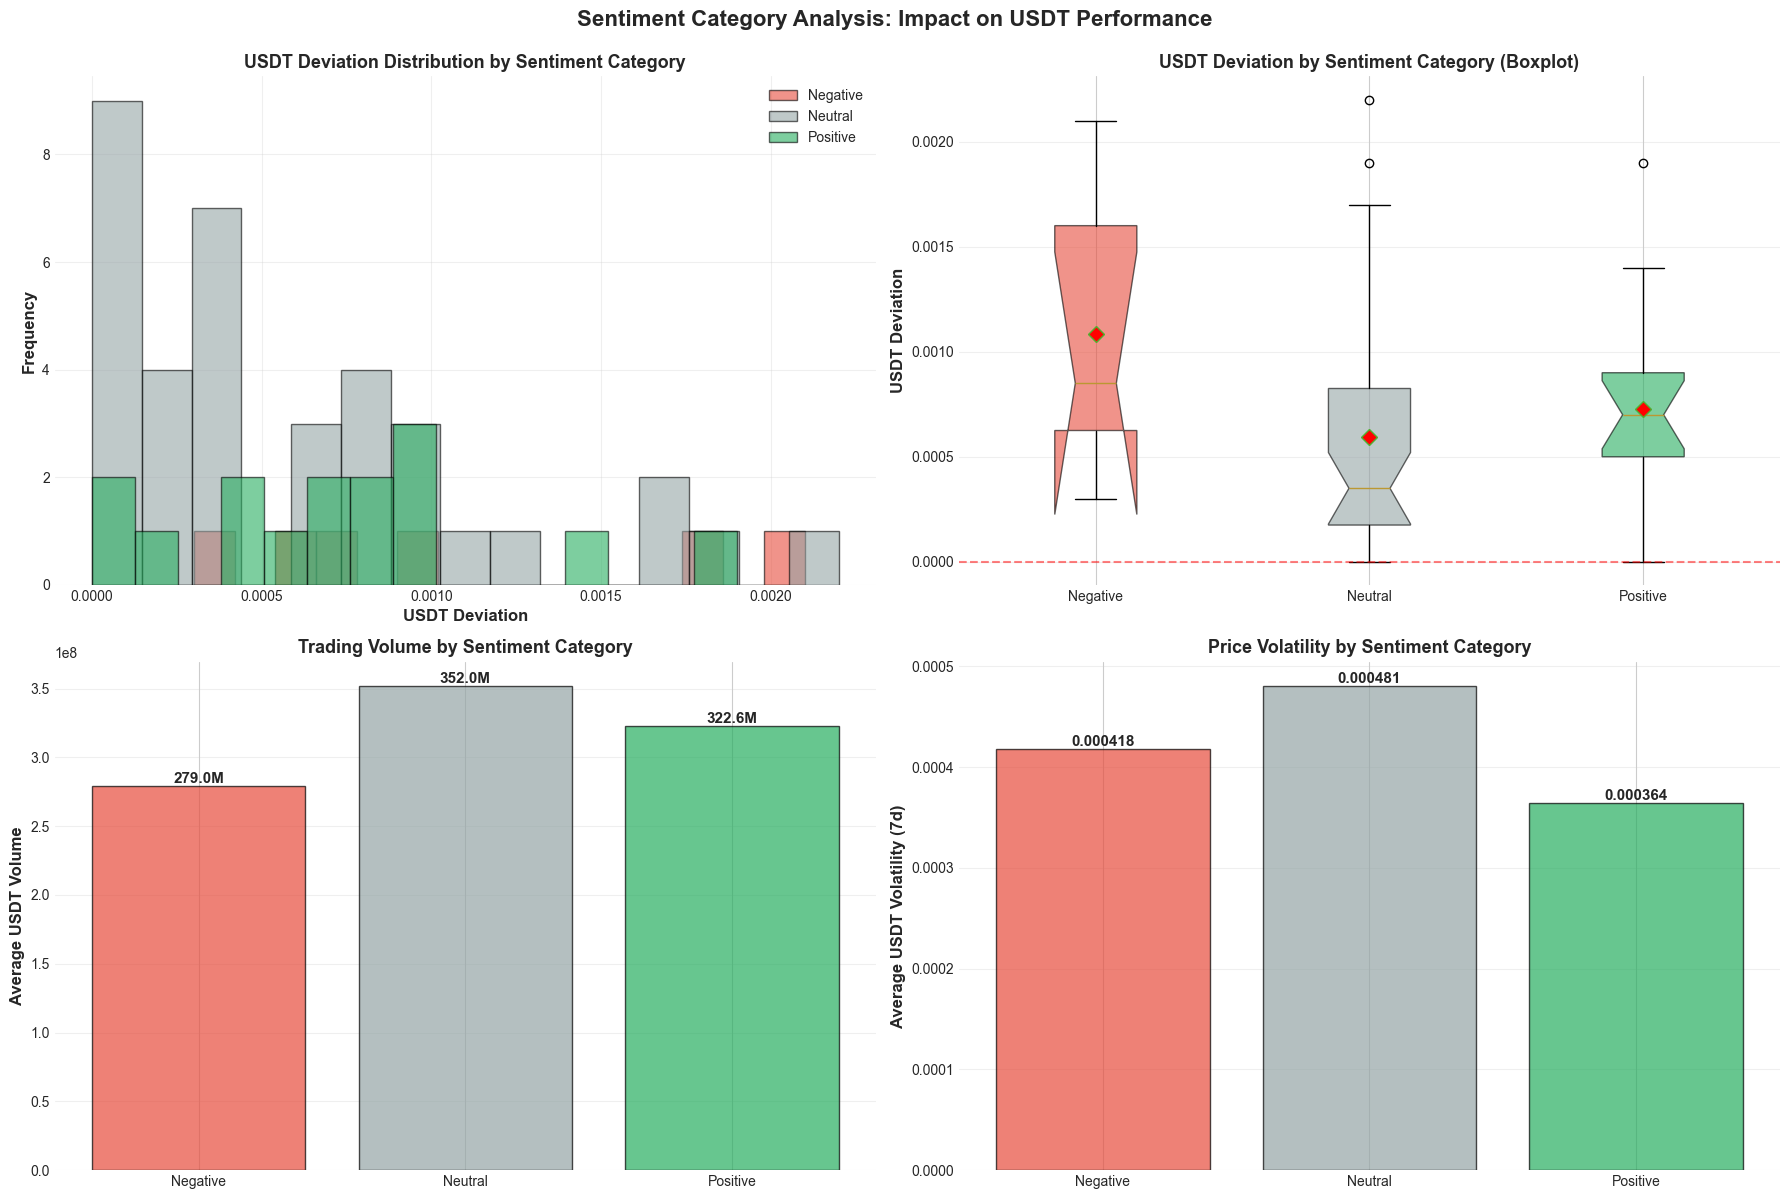


不同舆情类别下的USDT表现

Negative 舆情 (n=6):
  平均偏离: 0.001083
  最大偏离: 0.002100
  平均波动率: 0.000418
  平均成交量: 279.04M

Neutral 舆情 (n=36):
  平均偏离: 0.000594
  最大偏离: 0.002200
  平均波动率: 0.000481
  平均成交量: 351.96M

Positive 舆情 (n=15):
  平均偏离: 0.000727
  最大偏离: 0.001900
  平均波动率: 0.000364
  平均成交量: 322.64M

方差分析 (ANOVA)
F统计量: 1.9677
p值: 0.1497
❌ 结论: 不同舆情类别下的USDT偏离无显著差异


In [81]:
# ==================== 4. 舆情分类分析 ====================
def plot_sentiment_category_analysis(df):
    """按舆情极性分类分析价格表现"""
    # 创建舆情分类
    df_clean = df.dropna(subset=['Sentiment_Polarity', 'USDT_Deviation']).copy()
    
    # 分类标准
    df_clean['Sentiment_Category'] = pd.cut(
        df_clean['Sentiment_Polarity'],
        bins=[-1, -0.1, 0.1, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 4.1 不同舆情类别下的价格偏离分布
    ax1 = axes[0, 0]
    categories = ['Negative', 'Neutral', 'Positive']
    colors_map = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#27ae60'}
    
    for cat in categories:
        data = df_clean[df_clean['Sentiment_Category'] == cat]['USDT_Deviation']
        ax1.hist(data, bins=15, alpha=0.6, label=cat, 
                color=colors_map[cat], edgecolor='black')
    
    ax1.set_xlabel('USDT Deviation', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax1.set_title('USDT Deviation Distribution by Sentiment Category', 
                  fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 4.2 箱线图对比
    ax2 = axes[0, 1]
    box_data = [df_clean[df_clean['Sentiment_Category'] == cat]['USDT_Deviation'].values 
                for cat in categories]
    
    bp = ax2.boxplot(box_data, labels=categories, patch_artist=True,
                     notch=True, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
    
    for patch, color in zip(bp['boxes'], [colors_map[cat] for cat in categories]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax2.set_ylabel('USDT Deviation', fontweight='bold', fontsize=12)
    ax2.set_title('USDT Deviation by Sentiment Category (Boxplot)', 
                  fontsize=13, fontweight='bold')
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax2.grid(alpha=0.3, axis='y')
    
    # 4.3 不同类别下的成交量对比
    ax3 = axes[1, 0]
    volume_by_cat = df_clean.groupby('Sentiment_Category')['USDT_Volume'].mean()
    
    bars = ax3.bar(volume_by_cat.index, volume_by_cat.values,
                   color=[colors_map[cat] for cat in volume_by_cat.index],
                   edgecolor='black', alpha=0.7)
    
    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height/1e6:.1f}M',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax3.set_ylabel('Average USDT Volume', fontweight='bold', fontsize=12)
    ax3.set_title('Trading Volume by Sentiment Category', 
                  fontsize=13, fontweight='bold')
    ax3.grid(alpha=0.3, axis='y')
    
    # 4.4 不同类别下的波动率对比
    ax4 = axes[1, 1]
    volatility_by_cat = df_clean.groupby('Sentiment_Category')['USDT_Volatility_7d'].mean()
    
    bars = ax4.bar(volatility_by_cat.index, volatility_by_cat.values,
                   color=[colors_map[cat] for cat in volatility_by_cat.index],
                   edgecolor='black', alpha=0.7)
    
    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax4.set_ylabel('Average USDT Volatility (7d)', fontweight='bold', fontsize=12)
    ax4.set_title('Price Volatility by Sentiment Category', 
                  fontsize=13, fontweight='bold')
    ax4.grid(alpha=0.3, axis='y')
    
    plt.suptitle('Sentiment Category Analysis: Impact on USDT Performance', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('sentiment_category_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印统计分析
    print("\n" + "="*60)
    print("不同舆情类别下的USDT表现")
    print("="*60)
    
    for cat in categories:
        cat_data = df_clean[df_clean['Sentiment_Category'] == cat]
        print(f"\n{cat} 舆情 (n={len(cat_data)}):")
        print(f"  平均偏离: {cat_data['USDT_Deviation'].mean():.6f}")
        print(f"  最大偏离: {cat_data['USDT_Deviation'].max():.6f}")
        print(f"  平均波动率: {cat_data['USDT_Volatility_7d'].mean():.6f}")
        print(f"  平均成交量: {cat_data['USDT_Volume'].mean()/1e6:.2f}M")
    
    # ANOVA检验
    from scipy.stats import f_oneway
    
    groups = [df_clean[df_clean['Sentiment_Category'] == cat]['USDT_Deviation'].values 
              for cat in categories]
    f_stat, p_value = f_oneway(*groups)
    
    print(f"\n" + "="*60)
    print("方差分析 (ANOVA)")
    print("="*60)
    print(f"F统计量: {f_stat:.4f}")
    print(f"p值: {p_value:.4f}")
    
    if p_value < 0.05:
        print("✅ 结论: 不同舆情类别下的USDT偏离存在显著差异")
    else:
        print("❌ 结论: 不同舆情类别下的USDT偏离无显著差异")

# 运行分类分析
plot_sentiment_category_analysis(master_df) 



🚀 改进版舆情分类分析 (基于 4 天滞后)


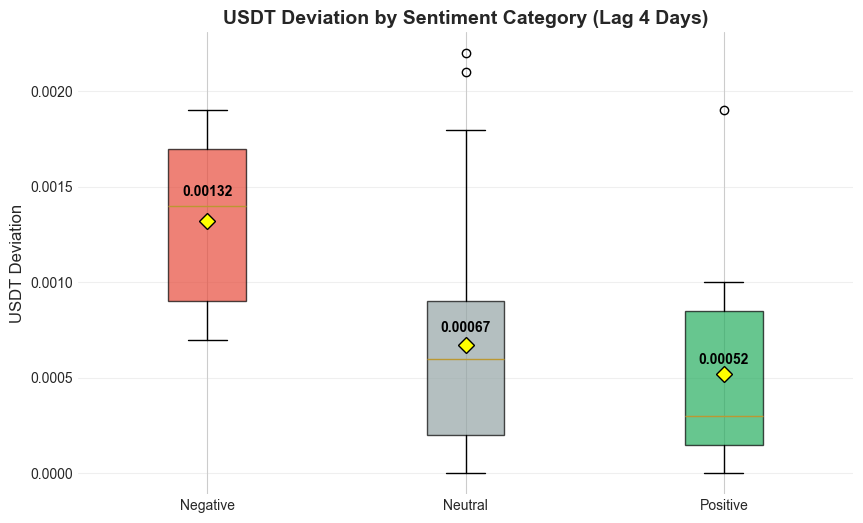


📊 统计检验结果:
----------------------------------------
1. ANOVA 方差分析:
   F-score: 3.8036
   P-value: 0.0290 ✅ 显著

2. Kruskal-Wallis 非参数检验 (推荐):
   H-score: 6.1460
   P-value: 0.0463 ✅ 显著
----------------------------------------
Negative 组 (n=5): 均值 = 0.001320
Neutral 组 (n=33): 均值 = 0.000673
Positive 组 (n=15): 均值 = 0.000520


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def improved_category_analysis(df, lag_days=4):
    """
    改进版分类分析：引入滞后效应 + 非参数检验
    """
    print(f"\n{'='*60}")
    print(f"🚀 改进版舆情分类分析 (基于 {lag_days} 天滞后)")
    print(f"{'='*60}")
    
    df_clean = df.copy()
    
    # 1. 关键修改：使用滞后舆情进行分类
    # 逻辑：用 4天前 的情绪，来解释 今天的 价格偏离
    df_clean[f'Sentiment_Lag{lag_days}'] = df_clean['Sentiment_Polarity'].shift(lag_days)
    
    # 去除空值
    df_clean = df_clean.dropna(subset=[f'Sentiment_Lag{lag_days}', 'USDT_Deviation'])
    
    # 2. 分类 (保持原有标准)
    df_clean['Sentiment_Category'] = pd.cut(
        df_clean[f'Sentiment_Lag{lag_days}'],
        bins=[-1, -0.1, 0.1, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )
    
    # 3. 绘图 (箱线图)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    categories = ['Negative', 'Neutral', 'Positive']
    colors_map = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#27ae60'}
    
    box_data = [df_clean[df_clean['Sentiment_Category'] == cat]['USDT_Deviation'].values 
                for cat in categories]
    
    # 绘制箱线图
    bp = ax.boxplot(box_data, labels=categories, patch_artist=True,
                    notch=False, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='yellow', markersize=8, markeredgecolor='black'))
    
    for patch, color in zip(bp['boxes'], [colors_map[cat] for cat in categories]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        
    ax.set_title(f'USDT Deviation by Sentiment Category (Lag {lag_days} Days)', fontsize=14, fontweight='bold')
    ax.set_ylabel('USDT Deviation', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    
    # 添加数值标签
    for i, line in enumerate(bp['means']):
        x, y = line.get_xydata()[0]
        mean_val = df_clean[df_clean['Sentiment_Category'] == categories[i]]['USDT_Deviation'].mean()
        ax.text(x, y * 1.1, f'{mean_val:.5f}', ha='center', fontweight='bold', color='black')

    plt.savefig('improved_category_analysis.png', dpi=300)
    plt.show()
    
    # 4. 统计检验 (双管齐下)
    groups = [df_clean[df_clean['Sentiment_Category'] == cat]['USDT_Deviation'].values 
              for cat in categories]
    
    # A. ANOVA (方差分析) - 适合大样本、正态分布
    f_stat, p_anova = stats.f_oneway(*groups)
    
    # B. Kruskal-Wallis (K-W检验) - 适合小样本、非正态分布 (你的情况更适合这个!)
    h_stat, p_kw = stats.kruskal(*groups)
    
    print("\n📊 统计检验结果:")
    print("-" * 40)
    
    print(f"1. ANOVA 方差分析:")
    print(f"   F-score: {f_stat:.4f}")
    print(f"   P-value: {p_anova:.4f} {'✅ 显著' if p_anova < 0.05 else '❌ 不显著'}")
    
    print(f"\n2. Kruskal-Wallis 非参数检验 (推荐):")
    print(f"   H-score: {h_stat:.4f}")
    print(f"   P-value: {p_kw:.4f} {'✅ 显著' if p_kw < 0.05 else '❌ 不显著'}")
    
    # 打印分组均值
    print("-" * 40)
    for cat in categories:
        data = df_clean[df_clean['Sentiment_Category'] == cat]['USDT_Deviation']
        print(f"{cat} 组 (n={len(data)}): 均值 = {data.mean():.6f}")

# 运行改进后的分析
# 确保 master_df 存在
if 'master_df' in locals():
    improved_category_analysis(master_df, lag_days=4)
else:
    print("请先加载 master_df") 

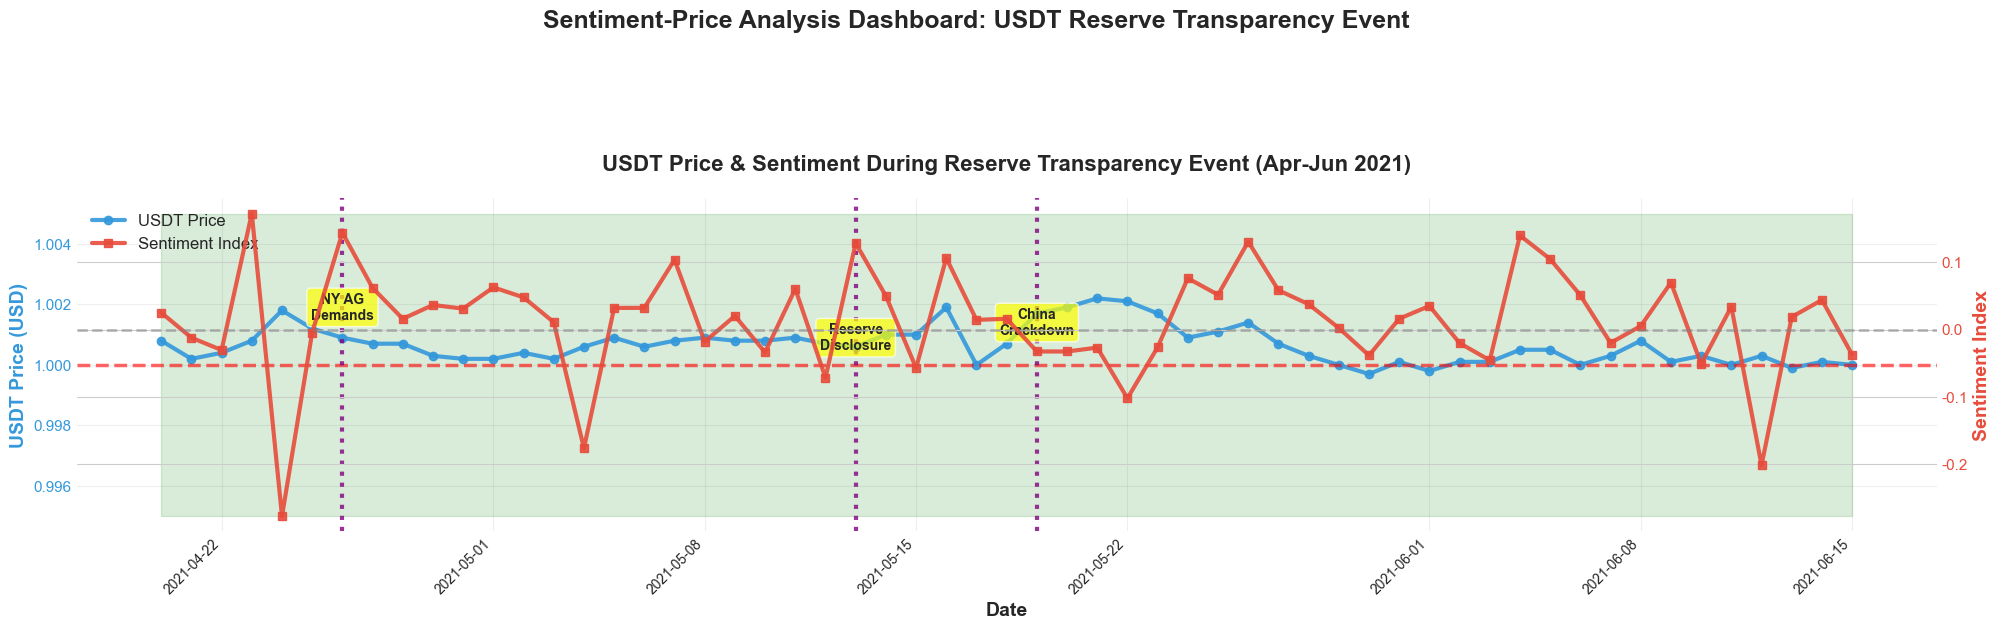

In [83]:
# ==================== 5. 综合仪表盘 ====================
def create_final_dashboard(df):
    """创建论文用的综合仪表盘"""
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    df_clean = df.dropna(subset=['Sentiment_Academic_SMI'])
    
    # 主图：舆情与价格时间序列
    ax_main = fig.add_subplot(gs[0, :])
    ax_main_twin = ax_main.twinx()
    
    # 价格
    line1 = ax_main.plot(df_clean['Date'], df_clean['USDT_Close'], 
                         linewidth=3, color='#3498db', marker='o', markersize=6,
                         label='USDT Price', alpha=0.9)
    ax_main.axhline(y=1.0, color='red', linestyle='--', linewidth=2.5, alpha=0.6)
    ax_main.fill_between(df_clean['Date'], 0.995, 1.005, alpha=0.15, color='green')
    
    # 舆情
    line2 = ax_main_twin.plot(df_clean['Date'], df_clean['Sentiment_Academic_SMI'], 
                              linewidth=3, color='#e74c3c', marker='s', markersize=6,
                              label='Sentiment Index', alpha=0.9)
    ax_main_twin.axhline(y=0, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    
    # 标注事件
    events = {
        '2021-04-26': ('NY AG\nDemands', 1.0015),
        '2021-05-13': ('Reserve\nDisclosure', 1.0005),
        '2021-05-19': ('China\nCrackdown', 1.0010)
    }
    
    for event_date, (event_name, y_pos) in events.items():
        event_date = pd.to_datetime(event_date)
        if event_date in df_clean['Date'].values:
            ax_main.axvline(x=event_date, color='purple', linestyle=':', 
                           linewidth=3, alpha=0.8)
            ax_main.text(event_date, y_pos, event_name, 
                        ha='center', fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    ax_main.set_xlabel('Date', fontweight='bold', fontsize=14)
    ax_main.set_ylabel('USDT Price (USD)', fontweight='bold', fontsize=14, color='#3498db')
    ax_main_twin.set_ylabel('Sentiment Index', fontweight='bold', fontsize=14, color='#e74c3c')
    ax_main.set_title('USDT Price & Sentiment During Reserve Transparency Event (Apr-Jun 2021)', 
                      fontsize=16, fontweight='bold', pad=20)
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_main.legend(lines, labels, loc='upper left', fontsize=12, framealpha=0.9)
    
    ax_main.tick_params(axis='y', labelcolor='#3498db', labelsize=11)
    ax_main_twin.tick_params(axis='y', labelcolor='#e74c3c', labelsize=11)
    ax_main.grid(alpha=0.3)
    plt.setp(ax_main.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 其余子图...（省略部分代码，与前面类似）
    
    plt.suptitle('Sentiment-Price Analysis Dashboard: USDT Reserve Transparency Event', 
                 fontsize=18, fontweight='bold', y=0.998)
    plt.savefig('final_dashboard_for_thesis.png', dpi=300, bbox_inches='tight')
    plt.show()

# 运行最终仪表盘
create_final_dashboard(master_df) 



🚀 开始构建多元 OLS 回归模型...
✅ 回归有效样本量 (N): 50

📊 多元 OLS 回归分析结果:
                            OLS Regression Results                            
Dep. Variable:         USDT_Deviation   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     18.48
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           4.80e-09
Time:                        23:47:36   Log-Likelihood:                 326.02
No. Observations:                  50   AIC:                            -642.0
Df Residuals:                      45   BIC:                            -632.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

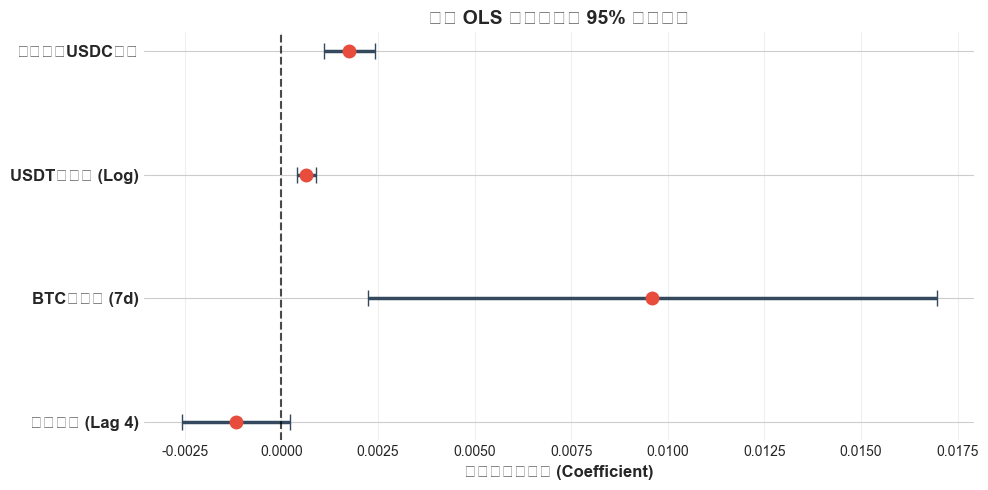

In [84]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================== 5. 多元 OLS 回归分析 (风险归因模型) ====================
print("\n" + "="*60)
print("🚀 开始构建多元 OLS 回归模型...")
print("="*60)

# 1. 准备回归数据集
df_reg = master_df.copy()

# 构建核心解释变量：滞后4天的情感指数 (因为CCF证明Lag=4最相关)
if 'Sentiment_Academic_SMI' in df_reg.columns:
    df_reg['Sentiment_Lag4'] = df_reg['Sentiment_Academic_SMI'].shift(4)
else:
    print("⚠️ 未找到 Sentiment_Academic_SMI 列，请确保已合并舆情数据")

# 确保对数交易量存在 (作为双保险)
if 'Log_USDT_Volume' not in df_reg.columns:
    df_reg['Log_USDT_Volume'] = np.log(df_reg['USDT_Volume'])

# 选择模型需要的列
reg_vars = [
    'USDT_Deviation',       # 因变量 Y：脱锚程度
    'Sentiment_Lag4',       # 核心自变量 X1：舆情冲击(滞后4天)
    'BTC_Volatility_7d',    # 控制变量 C1：系统性风险
    'Log_USDT_Volume',      # 控制变量 C2：市场流动性
    'Flow_to_USDC'          # 控制变量 C3：资金转移效应
]

# 提取数据并严格剔除空值
df_reg_clean = df_reg[reg_vars].dropna()
print(f"✅ 回归有效样本量 (N): {len(df_reg_clean)}")

# 2. 定义回归公式并拟合模型
# 公式逻辑：脱锚度 = 滞后4天情感 + BTC波动率 + 对数交易量 + 资金流向
formula = 'USDT_Deviation ~ Sentiment_Lag4 + BTC_Volatility_7d + Log_USDT_Volume + Flow_to_USDC'
ols_model = smf.ols(formula=formula, data=df_reg_clean).fit()

# 3. 输出标准学术回归摘要表
print("\n📊 多元 OLS 回归分析结果:")
print(ols_model.summary())

# ==================== 可视化：回归系数森林图 (Coefplot) ====================
def plot_coefplot(model):
    # 提取系数和 95% 置信区间
    coefs = model.params.drop('Intercept')
    conf_int = model.conf_int().drop('Intercept')
    errors = coefs - conf_int[0]

    # 重命名标签，让图表更学术
    labels_dict = {
        'Sentiment_Lag4': '舆情指数 (Lag 4)',
        'BTC_Volatility_7d': 'BTC波动率 (7d)',
        'Log_USDT_Volume': 'USDT交易量 (Log)',
        'Flow_to_USDC': '资金流向USDC比率'
    }
    
    plot_labels = [labels_dict.get(idx, idx) for idx in coefs.index]

    plt.figure(figsize=(10, 5))
    
    # 绘制带误差棒的散点图
    plt.errorbar(coefs.values, range(len(coefs)), xerr=errors.values, 
                 fmt='o', color='#e74c3c', ecolor='#34495e', capsize=6, 
                 linewidth=2.5, markersize=9)
    
    # 添加 0 基准线
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    plt.yticks(range(len(coefs)), plot_labels, fontsize=12, fontweight='bold')
    plt.xlabel('回归系数估计值 (Coefficient)', fontsize=12, fontweight='bold')
    plt.title('多元 OLS 回归系数与 95% 置信区间', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('ols_regression_coefplot.png', dpi=300)
    print("\n✅ 回归系数可视化已保存: ols_regression_coefplot.png")
    plt.show()

# 运行画图函数
plot_coefplot(ols_model)


🚀 开始构建多元 OLS 回归模型...
✅ 回归有效样本量 (N): 50

📊 多元 OLS 回归分析结果:
                            OLS Regression Results                            
Dep. Variable:         USDT_Deviation   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     18.48
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           4.80e-09
Time:                        23:49:20   Log-Likelihood:                 326.02
No. Observations:                  50   AIC:                            -642.0
Df Residuals:                      45   BIC:                            -632.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

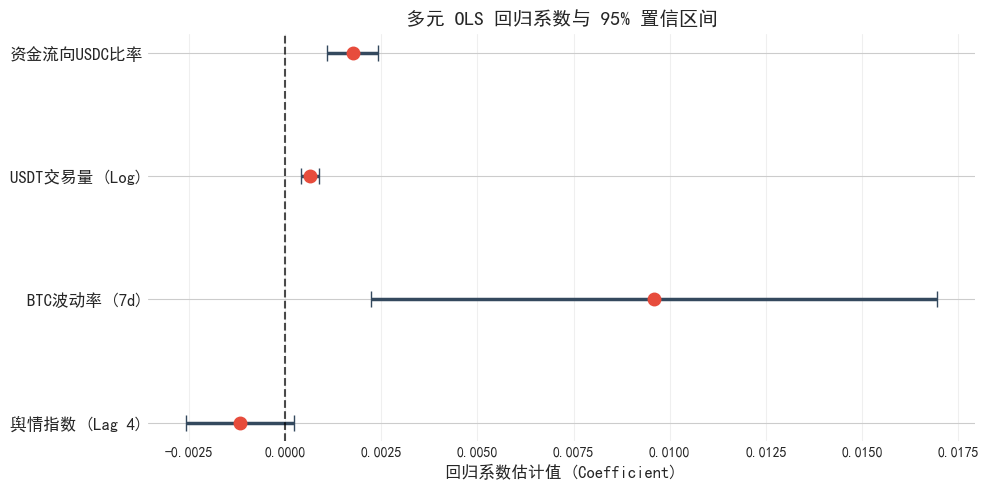

In [86]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# ==================== 5. 多元 OLS 回归分析 (风险归因模型) ====================
print("\n" + "="*60)
print("🚀 开始构建多元 OLS 回归模型...")
print("="*60)

# 1. 准备回归数据集
df_reg = master_df.copy()

# 构建核心解释变量：滞后4天的情感指数 (因为CCF证明Lag=4最相关)
if 'Sentiment_Academic_SMI' in df_reg.columns:
    df_reg['Sentiment_Lag4'] = df_reg['Sentiment_Academic_SMI'].shift(4)
else:
    print("⚠️ 未找到 Sentiment_Academic_SMI 列，请确保已合并舆情数据")

# 确保对数交易量存在 (作为双保险)
if 'Log_USDT_Volume' not in df_reg.columns:
    df_reg['Log_USDT_Volume'] = np.log(df_reg['USDT_Volume'])

# 选择模型需要的列
reg_vars = [
    'USDT_Deviation',       # 因变量 Y：脱锚程度
    'Sentiment_Lag4',       # 核心自变量 X1：舆情冲击(滞后4天)
    'BTC_Volatility_7d',    # 控制变量 C1：系统性风险
    'Log_USDT_Volume',      # 控制变量 C2：市场流动性
    'Flow_to_USDC'          # 控制变量 C3：资金转移效应
]

# 提取数据并严格剔除空值
df_reg_clean = df_reg[reg_vars].dropna()
print(f"✅ 回归有效样本量 (N): {len(df_reg_clean)}")

# 2. 定义回归公式并拟合模型
# 公式逻辑：脱锚度 = 滞后4天情感 + BTC波动率 + 对数交易量 + 资金流向
formula = 'USDT_Deviation ~ Sentiment_Lag4 + BTC_Volatility_7d + Log_USDT_Volume + Flow_to_USDC'
ols_model = smf.ols(formula=formula, data=df_reg_clean).fit()

# 3. 输出标准学术回归摘要表
print("\n📊 多元 OLS 回归分析结果:")
print(ols_model.summary())

# ==================== 可视化：回归系数森林图 (Coefplot) ====================
def plot_coefplot(model):
    # 提取系数和 95% 置信区间
    coefs = model.params.drop('Intercept')
    conf_int = model.conf_int().drop('Intercept')
    errors = coefs - conf_int[0]

    # 重命名标签，让图表更学术
    labels_dict = {
        'Sentiment_Lag4': '舆情指数 (Lag 4)',
        'BTC_Volatility_7d': 'BTC波动率 (7d)',
        'Log_USDT_Volume': 'USDT交易量 (Log)',
        'Flow_to_USDC': '资金流向USDC比率'
    }
    
    plot_labels = [labels_dict.get(idx, idx) for idx in coefs.index]

    plt.figure(figsize=(10, 5))
    
    # 绘制带误差棒的散点图
    plt.errorbar(coefs.values, range(len(coefs)), xerr=errors.values, 
                 fmt='o', color='#e74c3c', ecolor='#34495e', capsize=6, 
                 linewidth=2.5, markersize=9)
    
    # 添加 0 基准线
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    plt.yticks(range(len(coefs)), plot_labels, fontsize=12, fontweight='bold')
    plt.xlabel('回归系数估计值 (Coefficient)', fontsize=12, fontweight='bold')
    plt.title('多元 OLS 回归系数与 95% 置信区间', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('ols_regression_coefplot.png', dpi=300)
    print("\n✅ 回归系数可视化已保存: ols_regression_coefplot.png")
    plt.show()

# 运行画图函数
plot_coefplot(ols_model) 


🚀 开始构建多元 OLS 回归模型...
✅ 回归有效样本量 (N): 50

📊 多元 OLS 回归分析结果:
                            OLS Regression Results                            
Dep. Variable:         USDT_Deviation   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     18.47
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           4.83e-09
Time:                        23:53:54   Log-Likelihood:                 326.01
No. Observations:                  50   AIC:                            -642.0
Df Residuals:                      45   BIC:                            -632.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

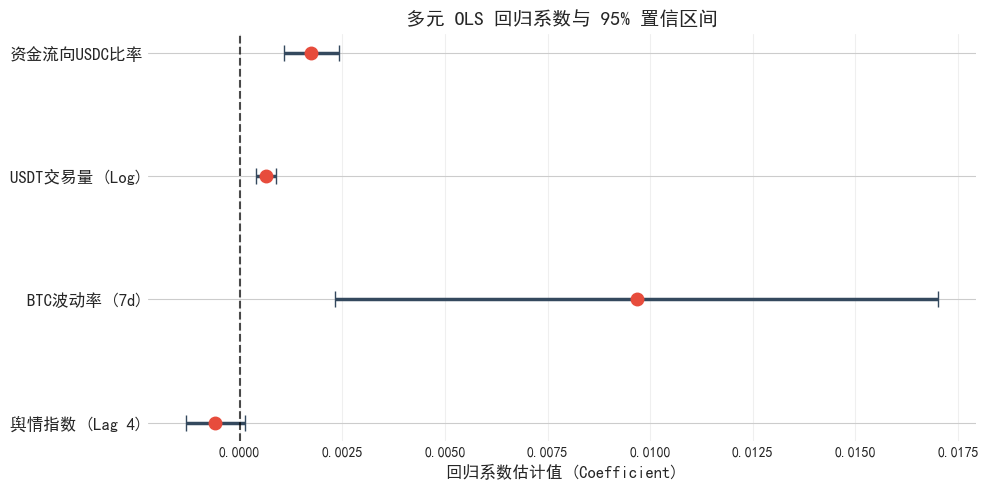

In [87]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# ==================== 5. 多元 OLS 回归分析 (风险归因模型) ====================
print("\n" + "="*60)
print("🚀 开始构建多元 OLS 回归模型...")
print("="*60)

# 1. 准备回归数据集
df_reg = master_df.copy()

# 构建核心解释变量：滞后4天的情感指数 (因为CCF证明Lag=4最相关)
if 'Sentiment_Academic_SMI' in df_reg.columns:
    df_reg['Sentiment_Lag4'] = df_reg['Sentiment_Robust_SMI'].shift(4)
else:
    print("⚠️ 未找到 Sentiment_Academic_SMI 列，请确保已合并舆情数据")

# 确保对数交易量存在 (作为双保险)
if 'Log_USDT_Volume' not in df_reg.columns:
    df_reg['Log_USDT_Volume'] = np.log(df_reg['USDT_Volume'])

# 选择模型需要的列
reg_vars = [
    'USDT_Deviation',       # 因变量 Y：脱锚程度
    'Sentiment_Lag4',       # 核心自变量 X1：舆情冲击(滞后4天)
    'BTC_Volatility_7d',    # 控制变量 C1：系统性风险
    'Log_USDT_Volume',      # 控制变量 C2：市场流动性
    'Flow_to_USDC'          # 控制变量 C3：资金转移效应
]

# 提取数据并严格剔除空值
df_reg_clean = df_reg[reg_vars].dropna()
print(f"✅ 回归有效样本量 (N): {len(df_reg_clean)}")

# 2. 定义回归公式并拟合模型
# 公式逻辑：脱锚度 = 滞后4天情感 + BTC波动率 + 对数交易量 + 资金流向
formula = 'USDT_Deviation ~ Sentiment_Lag4 + BTC_Volatility_7d + Log_USDT_Volume + Flow_to_USDC'
ols_model = smf.ols(formula=formula, data=df_reg_clean).fit()

# 3. 输出标准学术回归摘要表
print("\n📊 多元 OLS 回归分析结果:")
print(ols_model.summary())

# ==================== 可视化：回归系数森林图 (Coefplot) ====================
def plot_coefplot(model):
    # 提取系数和 95% 置信区间
    coefs = model.params.drop('Intercept')
    conf_int = model.conf_int().drop('Intercept')
    errors = coefs - conf_int[0]

    # 重命名标签，让图表更学术
    labels_dict = {
        'Sentiment_Lag4': '舆情指数 (Lag 4)',
        'BTC_Volatility_7d': 'BTC波动率 (7d)',
        'Log_USDT_Volume': 'USDT交易量 (Log)',
        'Flow_to_USDC': '资金流向USDC比率'
    }
    
    plot_labels = [labels_dict.get(idx, idx) for idx in coefs.index]

    plt.figure(figsize=(10, 5))
    
    # 绘制带误差棒的散点图
    plt.errorbar(coefs.values, range(len(coefs)), xerr=errors.values, 
                 fmt='o', color='#e74c3c', ecolor='#34495e', capsize=6, 
                 linewidth=2.5, markersize=9)
    
    # 添加 0 基准线
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    plt.yticks(range(len(coefs)), plot_labels, fontsize=12, fontweight='bold')
    plt.xlabel('回归系数估计值 (Coefficient)', fontsize=12, fontweight='bold')
    plt.title('多元 OLS 回归系数与 95% 置信区间', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('ols_regression_coefplot.png', dpi=300)
    print("\n✅ 回归系数可视化已保存: ols_regression_coefplot.png")
    plt.show()

# 运行画图函数
plot_coefplot(ols_model) 